# Libraries


In [1]:
#Used for the first time in "Pathway to save figures"
import os
#Used for the first time in "Import DATA"
import pandas as pd
#Used for the first time in "Principal Component Analyses"
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Used for the first time in "Hierarchical clustering"
import umap
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from scipy.stats import chi2
from matplotlib.colors import to_hex
from matplotlib.patches import Ellipse
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import set_link_color_palette
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from itertools import product
import joblib
from scipy.spatial import procrustes
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import warnings
 
#Used for the first time in "Release properties"
import seaborn as sns

#Used for the first time in "Check if data are comparable" - Statistical annotations
from scipy.stats import kruskal
from statannotations.Annotator import Annotator


#Some module create warnings for futur updates. Here we ignore them. Erase following line to restaure warnings.
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

# Pathway to save figures

In [2]:
output_dir = r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures"
os.makedirs(output_dir, exist_ok=True)

# Import data
The PCA will use only the columns AMP1, AMP2, all PPRs and %Fail1 and 2. All the other columns will be un-selected.

In [3]:
#WT experiments
df_WT_pooled  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="WT_pooled")
df_WT_Theo    = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="WT_Theo")
df_WT_Anthime = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="WT_Anthime")

#SynII experiments
df_SynII      = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="SynII")

#Calcium experiments
df_WT_1_5Ca   = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=0)
df_WT_4Ca     = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=1)

### Check if data are comparable

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT_Theo vs. WT_Anthime: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:3.002e-01 Stat=2.704e+00
WT_Anthime vs. SynII: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:4.386e-01 Stat=2.111e+00
WT_Theo vs. SynII: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:3.002e-06 Stat=2.393e+01
Kruskal-Wallis test for PPR2/1: H = 22.786, p = 0.000011
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT_Theo vs. WT_Anthime: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:1.000e+00 Stat=

KeyError: 'STD_baseline'

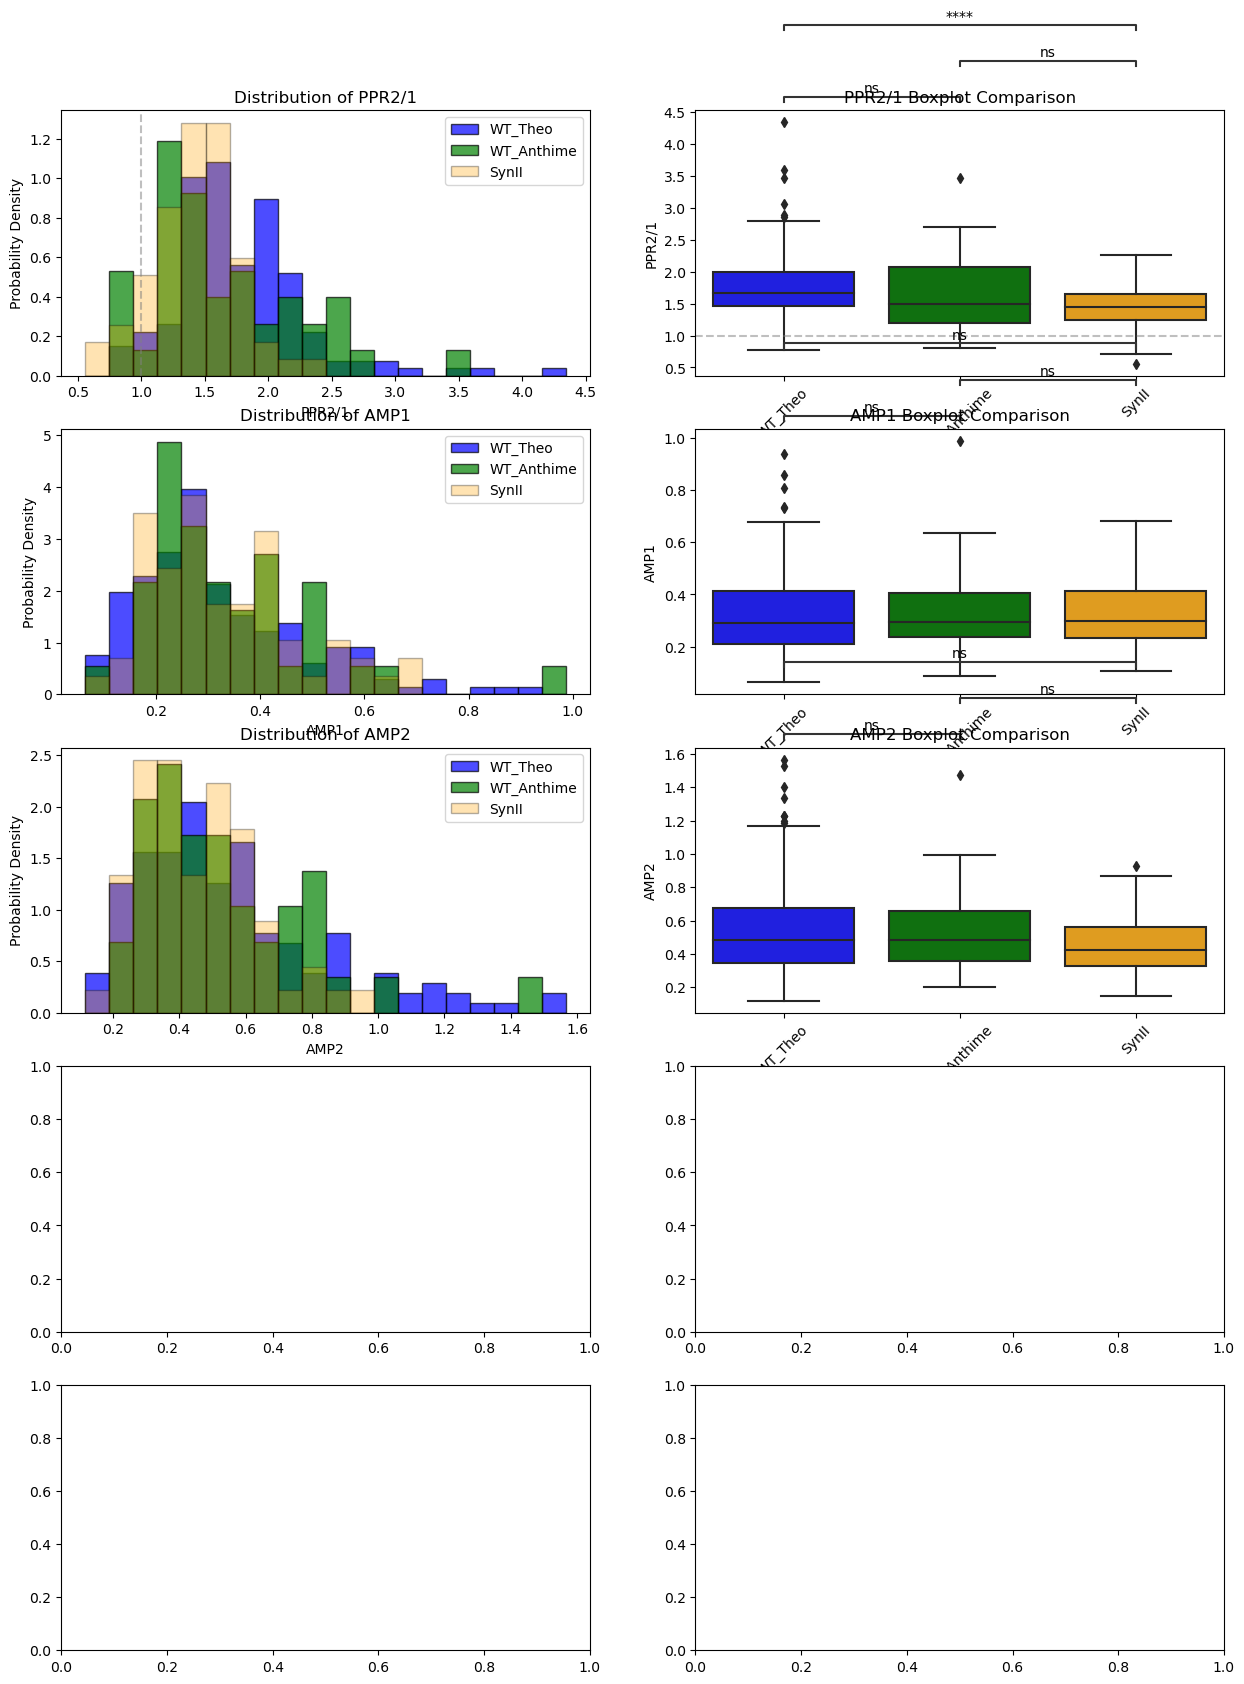

In [60]:
# Create a 5x2 subplot showing histograms (left) and boxplots (right) for different parameters
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

# Use the already loaded datasets from the previous cell
datasets = {
    'WT_Theo': df_WT_Theo,
    'WT_Anthime': df_WT_Anthime, 
    'SynII': df_SynII
}
colors = ['blue', 'green', 'orange']

# Define parameters to analyze
parameters = ['PPR2/1', 'AMP1', 'AMP2', 'STD_baseline', '%Fail1']
special_lines = {'PPR2/1': 1}  # Parameters that need horizontal reference lines

# Define pairwise comparisons for statistical testing
comparisons = [
    ("WT_Theo", "SynII"),
    ("WT_Theo", "WT_Anthime"),
    ("WT_Anthime", "SynII"),
]

# Loop through each parameter
for i, param in enumerate(parameters):
    # Calculate global range for this parameter
    all_data = []
    for dataset in datasets.values():
        all_data.extend(dataset[param].dropna())
    bins = np.linspace(min(all_data), max(all_data), 21)  # 20 bins
    
    # Histogram (left column)
    for j, (name, dataset) in enumerate(datasets.items()):
        axes[i, 0].hist(dataset[param].dropna(), bins=bins, 
                       edgecolor='black', alpha=0.7 if name != 'SynII' else 0.3, 
                       label=name, color=colors[j], density=True)
    
    axes[i, 0].set_xlabel(param)
    axes[i, 0].set_ylabel('Probability Density')
    axes[i, 0].set_title(f'Distribution of {param}')
    axes[i, 0].legend()
    
    # Add special horizontal lines if needed
    if param in special_lines:
        axes[i, 0].axvline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
    
    # Boxplot with statistical annotations (right column)
    # Create combined DataFrame for this parameter
    param_frames = []
    for name, dataset in datasets.items():
        param_frames.append(dataset[[param]].assign(Source=name))
    param_combined_df = pd.concat(param_frames, ignore_index=True)
    
    ax = axes[i, 1]
    sns.boxplot(data=param_combined_df, x='Source', y=param, ax=ax, palette=colors)
    
    # Add special horizontal lines if needed
    if param in special_lines:
        ax.axhline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
    
    # Apply statistical annotations
    try:
        annotator = Annotator(ax, comparisons, data=param_combined_df, x='Source', y=param)
        annotator.configure(test='Kruskal', text_format='star', loc='outside', 
                          comparisons_correction='bonferroni')
        annotator.apply_and_annotate()
    except Exception as e:
        print(f"Warning: Could not add statistical annotations for {param}: {e}")
    
    ax.set_ylabel(param)
    ax.set_title(f'{param} Boxplot Comparison')
    ax.tick_params(axis='x', rotation=45)
    
    # Perform overall Kruskal-Wallis test
    param_groups = [datasets[name][param].dropna() for name in datasets.keys()]
    param_kruskal_stat, param_kruskal_p = kruskal(*param_groups)
    print(f"Kruskal-Wallis test for {param}: H = {param_kruskal_stat:.3f}, p = {param_kruskal_p:.6f}")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "parameter_comparison_histograms_boxplot.pdf"))
plt.show()

### Checking of the mean PPR profile 

For SynII, WT Anthime, WT Théo. Without considering any cluster for now.

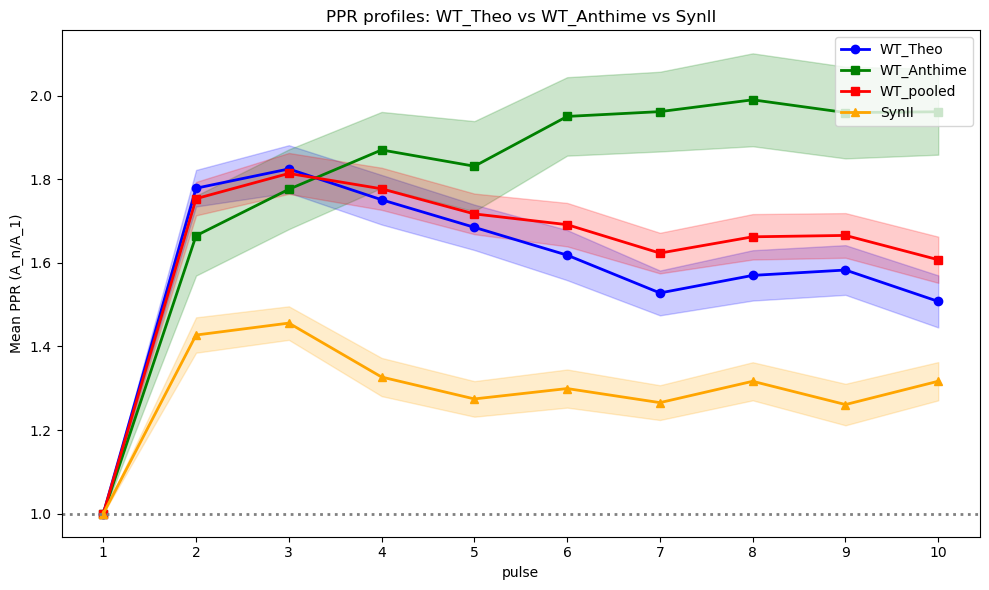

In [5]:
# Plot PPR profiles for WT_Theo and WT_Anthime with SEM
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_Theo.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10

plt.figure(figsize=(10, 6))

# Calculate means and SEMs for WT_Theo
means_theo = [1] + df_WT_Theo[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_theo = [0] + df_WT_Theo[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for WT_Anthime
means_anthime = [1] + df_WT_Anthime[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_anthime = [0] + df_WT_Anthime[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for WT_pooled
means_pooled = [1] + df_WT_pooled[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_pooled = [0] + df_WT_pooled[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for SynII
means_synii = [1] + df_SynII[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_synii = [0] + df_SynII[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Plot WT_Theo PPR profile
plt.plot(x_pulses, means_theo, marker='o', label='WT_Theo', color='blue', linewidth=2)
plt.fill_between(x_pulses, np.array(means_theo)-np.array(sems_theo), 
                 np.array(means_theo)+np.array(sems_theo), alpha=0.2, color='blue')

# Plot WT_Anthime PPR profile
plt.plot(x_pulses, means_anthime, marker='s', label='WT_Anthime', color='green', linewidth=2)
plt.fill_between(x_pulses, np.array(means_anthime)-np.array(sems_anthime), 
                 np.array(means_anthime)+np.array(sems_anthime), alpha=0.2, color='green')

# Plot pooled PPR profile
plt.plot(x_pulses, means_pooled, marker='s', label='WT_pooled', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(means_pooled)-np.array(sems_pooled), 
                 np.array(means_pooled)+np.array(sems_pooled), alpha=0.2, color='red')

# Plot SynII PPR profile
plt.plot(x_pulses, means_synii, marker='^', label='SynII', color='orange', linewidth=2)
plt.fill_between(x_pulses, np.array(means_synii)-np.array(sems_synii), 
                 np.array(means_synii)+np.array(sems_synii), alpha=0.2, color='orange')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles: WT_Theo vs WT_Anthime vs SynII')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_Theo_vs_Anthime_vs_SynII_PPR_profiles.pdf"))
plt.show()

### Checking the normalized traces.
Each traces were cut to be 1scd long, with 0.5scd for the baseline. Since the sampling rate wasn't the same for each condition (from the fastest to the slowest : WT théo [small linescan], SynII [parallel linescan, 4 lines], WT anthime [long parallel linescan, 4 to 6 lines]) it has been decided to downsample everything to a fix value (here 300Hz) so the amplitudes could be on a comparable basis. Indeed, more points could lead to a sharper and taller peak.

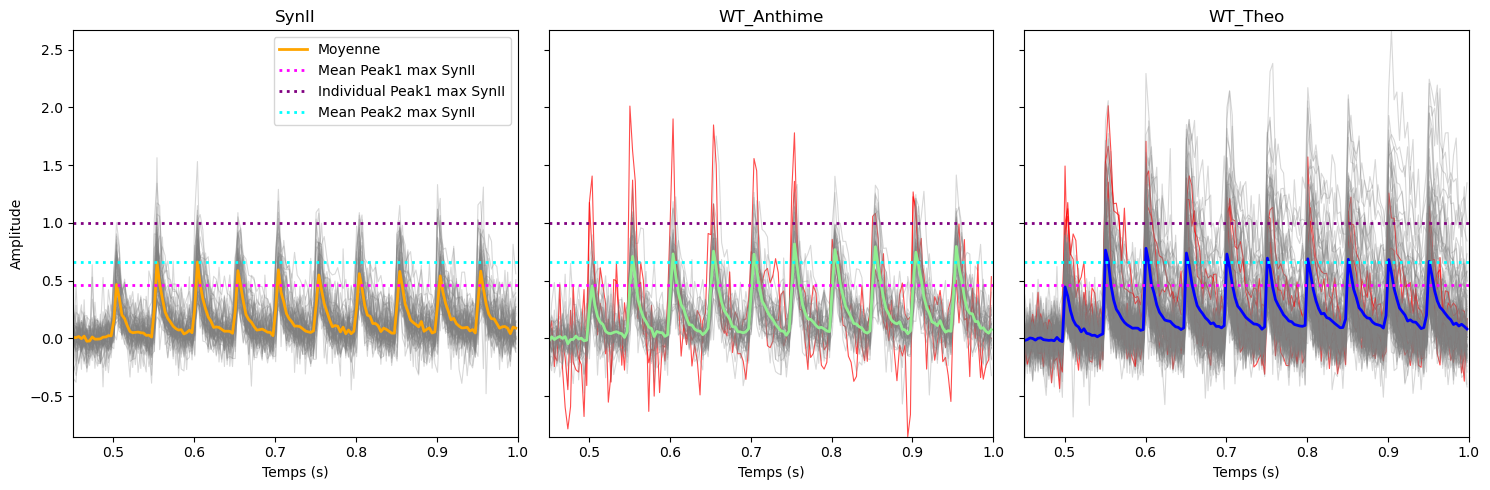


Traces WT_Anthime avec pic > seuil violet (n=2):
  241211_Fibre1_PortionA_bouton11
  241211_Fibre1_PortionA_bouton6

Traces WT_Theo avec pic > seuil violet (n=4):
  20210125_linescan1_20Hz_10pulses_2.5mMCa_bouton2
  20210128_linescan2_20Hz_10pulses_2.5mMCa_bouton5
  20210128_linescan4_20Hz_10pulses_2.5mMCa_bouton2
  20210301_linescan3_20Hz_10pulses_2.5mMCa_bouton5

Seuil violet (pic max traces SynII): 1.003


In [6]:
# Charger les traces
test_SynII = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="SynII")
test_wt_anthime = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Anthime")
test_wt_theo = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Theo")

# Extraire le temps
time = test_SynII.iloc[1:, 0].values.astype(float)

# Extraire les traces (toutes sauf la colonne temps)
traces_synii = test_SynII.iloc[1:, 1:].astype(float).values
traces_wt_anthime = test_wt_anthime.iloc[1:, 1:].astype(float).values
traces_wt_theo = test_wt_theo.iloc[1:, 1:].astype(float).values

# Moyennes
mean_synii = np.mean(traces_synii, axis=1)
mean_wt_anthime = np.mean(traces_wt_anthime, axis=1)
mean_wt_theo = np.mean(traces_wt_theo, axis=1)

# Mesure du pic SynII entre 0.5s et 0.53s
mask_peak = (time >= 0.5) & (time <= 0.53)
peak_amp_synii = mean_synii[mask_peak].max()

# Mesure du pic le plus haut des traces individuelles de SynII entre 0.5s et 0.53s
peak_synii_individual = traces_synii[mask_peak, :].max()

# Mesure du pic 2 de la moyenne SynII entre 0.55s et 0.58s
mask_peak2 = (time >= 0.55) & (time <= 0.58)
peak_amp_synii_2 = mean_synii[mask_peak2].max()

# Détermination des bornes globales pour l'échelle
all_traces = np.concatenate([traces_synii, traces_wt_anthime, traces_wt_theo], axis=1)
ymin = np.min(all_traces)
ymax = np.max(all_traces)

# Création de la figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot SynII
for trace in traces_synii.T:
    axes[0].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[0].plot(time, mean_synii, color='orange', linewidth=2, label='Moyenne')
axes[0].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[0].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[0].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[0].set_title('SynII')
axes[0].set_ylim(ymin, ymax)
axes[0].set_xlim(0.45, 1.0)
axes[0].legend()

# Plot WT_Anthime
red_traces_anthime = []
for i, trace in enumerate(traces_wt_anthime.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[1].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_anthime.append(test_wt_anthime.columns[i+1])  # +1 because first column is time
    else:
        axes[1].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[1].plot(time, mean_wt_anthime, color='lightgreen', linewidth=2, label='Moyenne')
axes[1].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[1].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[1].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[1].set_title('WT_Anthime')
axes[1].set_ylim(ymin, ymax)
axes[1].set_xlim(0.45, 1.0)

# Plot WT_Theo
red_traces_theo = []
for i, trace in enumerate(traces_wt_theo.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[2].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_theo.append(test_wt_theo.columns[i+1])  # +1 because first column is time
    else:
        axes[2].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[2].plot(time, mean_wt_theo, color='blue', linewidth=2, label='Moyenne')
axes[2].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[2].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[2].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[2].set_title('WT_Theo')
axes[2].set_ylim(ymin, ymax)
axes[2].set_xlim(0.45, 1.0)

for ax in axes:
    ax.set_xlabel('Temps (s)')
axes[0].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Traces_SynII_WTAnthime_WTTheo.pdf"))
plt.show()

# Print the IDs of traces in red (above purple threshold)
print(f"\nTraces WT_Anthime avec pic > seuil violet (n={len(red_traces_anthime)}):")
for trace_id in red_traces_anthime:
    print(f"  {trace_id}")

print(f"\nTraces WT_Theo avec pic > seuil violet (n={len(red_traces_theo)}):")
for trace_id in red_traces_theo:
    print(f"  {trace_id}")

print(f"\nSeuil violet (pic max traces SynII): {peak_synii_individual:.3f}")


### prepare data for analyses

In [7]:
#Get rids of the un-used columns for the PCA
df_WT_pooled  = df_WT_pooled.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1) 
df_WT_Theo    = df_WT_Theo.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1)
df_WT_Anthime = df_WT_Anthime.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_SynII      = df_SynII.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_WT_1_5Ca   = df_WT_1_5Ca .drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_WT_4Ca     = df_WT_4Ca.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)

#Extracts labels
labels = df_WT_pooled.columns

# Figure 1 : Four classes of STP and glutamate release properties at GC boutons

## 1 - Normalization

Normalization is essential before applying PCA or UMAP because these algorithms are sensitive to the scale of the variables. If features have different units or variances, those with larger scales can dominate the analysis and distort the results. By standardizing all features to have zero mean and unit variance, we ensure that each variable contributes equally to the dimensionality reduction and clustering steps.

In [8]:
#Creates a standard scaler object to normalize data
scaler = StandardScaler() 

#Fits scaler on df_WT_pooled (for means and std)
scaled_data_WT_pooled = scaler.fit_transform(df_WT_pooled)

#Applies the same scaling to all other datasets. For same feature space for PCA comparison
scaled_data_WT_Theo    = scaler.transform(df_WT_Theo)
scaled_data_WT_Anthime = scaler.transform(df_WT_Anthime)
scaled_data_SynII      = scaler.transform(df_SynII)
scaled_data_WT_1_5Ca   = scaler.transform(df_WT_1_5Ca)
scaled_data_WT_4Ca     = scaler.transform(df_WT_4Ca)

## 2 - PCA construction
PCA is performed on the entire WT_pooled dataset to capture the main axes of variation present in all samples. By using all available data, the principal components reflect the global structure and variability of the dataset, ensuring that the projection is representative and comparable across different experimental groups. PCA is a good choice because it reduces dimensionality while preserving as much variance as possible, making it easier to visualize complex data and identify patterns or clusters. Additionally, PCA provides orthogonal axes (principal components) that are uncorrelated, which simplifies downstream analyses and interpretation.

In [9]:
#Creates a PCA object that reduces the data to 2 principal components
reducer_PCA = PCA(n_components=2)

#Fits the PCA on scaled_data_WT_pooled (learns projection axes)
transformed_data_WT_pooled = reducer_PCA.fit_transform(scaled_data_WT_pooled)

# Projects all other scaled datasets into the same space defined by new_df
transformed_data_WT_Theo    = reducer_PCA.transform(scaled_data_WT_Theo)
transformed_data_WT_Anthime = reducer_PCA.transform(scaled_data_WT_Anthime)
transformed_data_SynII      = reducer_PCA.transform(scaled_data_SynII)
transformed_data_WT_1_5Ca   = reducer_PCA.transform(scaled_data_WT_1_5Ca)
transformed_data_WT_4Ca     = reducer_PCA.transform(scaled_data_WT_4Ca)

### Organisation

In [10]:
# Create a DataFrame with columns PC1 and PC2
transformed_WT_pooled  = pd.DataFrame(transformed_data_WT_pooled, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Theo    = pd.DataFrame(transformed_data_WT_Theo, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Anthime = pd.DataFrame(transformed_data_WT_Anthime, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_SynII      = pd.DataFrame(transformed_data_SynII, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_1_5Ca   = pd.DataFrame(transformed_data_WT_1_5Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_4Ca     = pd.DataFrame(transformed_data_WT_4Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])

### Few checks

In [11]:
print(" explained variance: ", reducer_PCA.explained_variance_ratio_)

 explained variance:  [0.57550649 0.20540066]


In [12]:
#Creates a DataFrame showing how much each original feature contributes to PC1 and PC2.
df_components = pd.DataFrame(reducer_PCA.components_, columns = labels, index = ['PC_1', 'PC_2'])
df_components

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC_1,-0.198657,-0.090979,0.255324,0.305358,0.326747,0.330194,0.332453,0.330865,0.332847,0.333671,0.325125,0.158987,0.070210
PC_2,0.439600,0.545912,0.199584,0.094910,0.081783,0.082134,0.066242,0.049503,0.059083,0.085570,0.063281,-0.442817,-0.478239


In [13]:
#Concatenates the PCA-transformed data (PC1, PC2) and the original features (new_df) into one table
full_table = pd.concat([transformed_WT_pooled, df_WT_pooled], axis=1, join='inner')

#Computes the correlation matrix between all columns in full_table. Shows how each principal component correlates with the original features
full_table_df = full_table.corr()

#Extracts only the correlations between PC1/PC2 and the original features
coeff_corr = full_table_df.iloc[0:2,2:]
coeff_corr

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC1,-0.543376,-0.248850,0.698373,0.835231,0.893734,0.903161,0.909341,0.904999,0.910419,0.912672,0.889299,0.434869,0.192042
PC2,0.718341,0.892062,0.326135,0.155090,0.133640,0.134214,0.108244,0.080892,0.096545,0.139828,0.103407,-0.723597,-0.781480


## OLD 3 - UMAP visualization

UMAP is used in addition to PCA because it can capture non-linear relationships and preserve both local and global data structure in a low-dimensional space.

### Hyperparameter optimization
In this step, the script performs an optimization of UMAP hyperparameters to obtain the best possible low-dimensional embedding of the data for clustering. For each combination, UMAP is run multiple times with different random seeds, and KMeans clustering is applied to the resulting embeddings. The Calinski-Harabasz score is used to evaluate the clustering quality for each run, and the average score across seeds is computed.  
The combination of UMAP parameters that yields the highest average Calinski-Harabasz score is selected as the best.

In [14]:
# Optimize UMAP hyperparameters using grid search and calinski_harabasz score
# Define parameter grid for UMAP
n_neighbors_list = [5, 10, 15, 30, 50]
min_dist_list = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
repulsion_strength_list = [1, 5, 10, 15, 20, 25, 30]
n_init = 5  # Number of random initializations for consensus

best_score = -1
best_params = None

# Use parallel processing for UMAP and KMeans

def evaluate_umap(params):
    n_neighbors, min_dist, repulsion_strength = params
    scores = []
    for seed in range(n_init):
        reducer_umap = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            repulsion_strength=repulsion_strength,
            random_state=42 + seed,
            n_jobs=-1  # Use all available cores
        )
        embedding = reducer_umap.fit_transform(scaled_data_WT_pooled)
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embedding)
        score = calinski_harabasz_score(embedding, cluster_labels)
        scores.append(score)
    avg_score = np.mean(scores)
    return (avg_score, n_neighbors, min_dist, repulsion_strength)

param_grid = list(product(n_neighbors_list, min_dist_list, repulsion_strength_list))
results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(evaluate_umap)(params) for params in param_grid
)

for avg_score, n_neighbors, min_dist, repulsion_strength in results:
    if avg_score > best_score:
        best_score = avg_score
        best_params = {
            'n_neighbors': n_neighbors,
            'min_dist': min_dist,
            'repulsion_strength': repulsion_strength
        }

print(f"Best UMAP parameters: {best_params}")
print(f"Best Calinski-Harabasz score: {best_score}")    

Best UMAP parameters: {'n_neighbors': 5, 'min_dist': 0.0005, 'repulsion_strength': 5}
Best Calinski-Harabasz score: 441.2645908176135


### OLD Consensus UMAP Embedding Alignment Using Procrustes Analysis

This cell generates multiple UMAP embeddings of the data using the optimal hyperparameters and different random seeds to account for UMAP's stochasticity. Each embedding is then aligned to the first embedding using Procrustes analysis, which removes differences in translation, scale, and rotation. The aligned embeddings are averaged to produce a consensus UMAP embedding, providing a stable and reproducible low-dimensional representation of the data. The resulting consensus embedding is visualized in a scatter plot.

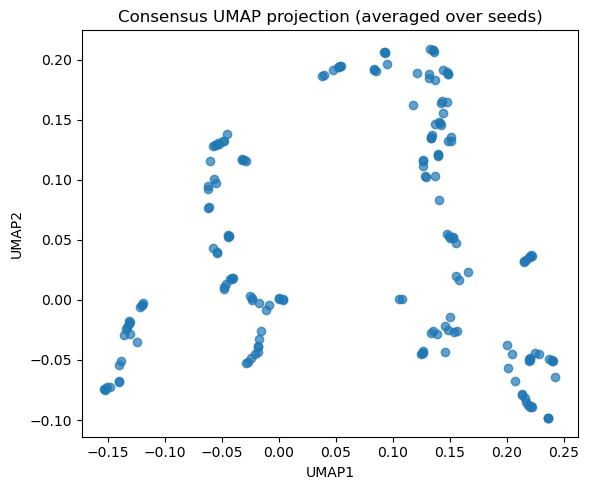

In [15]:
# Warning suppression for UMAP parallel processing.
import warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.")

# Run UMAP with the best parameters and average embeddings over multiple runs.
n_runs = 100
umap_embeddings = []

for seed in range(n_runs):
    reducer_umap = umap.UMAP(
        n_components=2,
        n_neighbors=best_params['n_neighbors'],
        min_dist=best_params['min_dist'],
        repulsion_strength=best_params['repulsion_strength'],
        random_state=seed,
        n_jobs=-1
    )
    emb = reducer_umap.fit_transform(scaled_data_WT_pooled)
    umap_embeddings.append(emb)

# Align all embeddings to the first one using Procrustes
aligned_embeddings = [umap_embeddings[0]]
for emb in umap_embeddings[1:]:
    mtx1, mtx2, disparity = procrustes(umap_embeddings[0], emb)
    aligned_embeddings.append(mtx2)

# Average the aligned embeddings
consensus_embedding = np.mean(aligned_embeddings, axis=0)

plt.figure(figsize=(6,5))
plt.scatter(consensus_embedding[:,0], consensus_embedding[:,1], alpha=0.7)
plt.title('Consensus UMAP projection (averaged over seeds)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

## 4 - Hierarchical clustering on PCA
By performing hierarchical clustering (HC) on the PCA embedding, we can identify clusters that may not be visible in the linear PCA projection. The resulting cluster labels are then projected back onto the PCA space to visualize how these non-linear clusters are distributed in the principal component axes.

### OLD - Cluster Number Selection Using Multiple Validation Metrics and Elbow Plot
This cell determines the optimal number of clusters for hierarchical clustering on the consensus UMAP embedding. It evaluates clustering quality across a range of cluster numbers (2–10) using three different metrics: Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index. For each metric, the optimal cluster number is identified and visualized in separate plots.   
Additionally, an elbow plot is generated using KMeans inertia, with a mono-exponential fit to help identify the "elbow" point.  
The final number of clusters (n_clust) is set to the value that maximizes the Silhouette Score, and this value is printed for use in subsequent analyses.  
  
  The silhouette score is optimal because it balances both cluster cohesion and separation.  

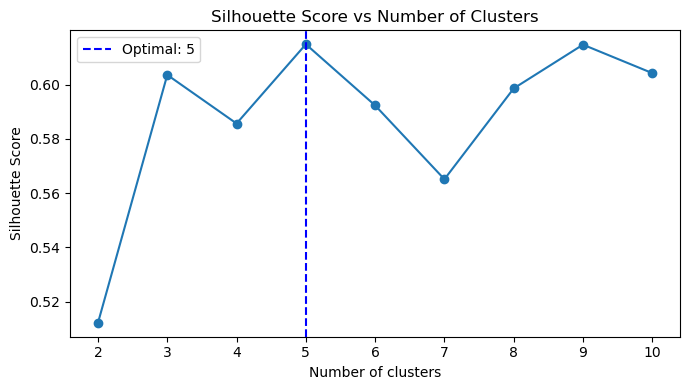

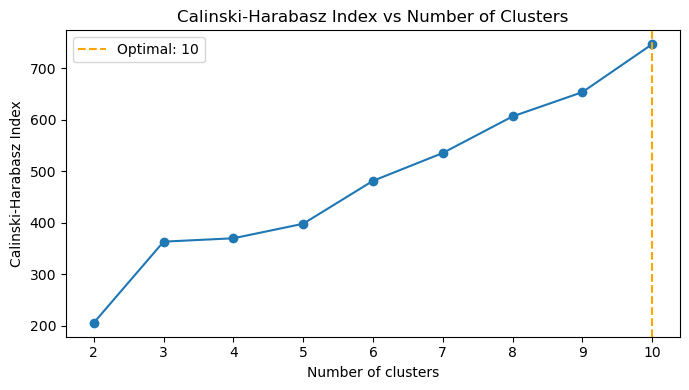

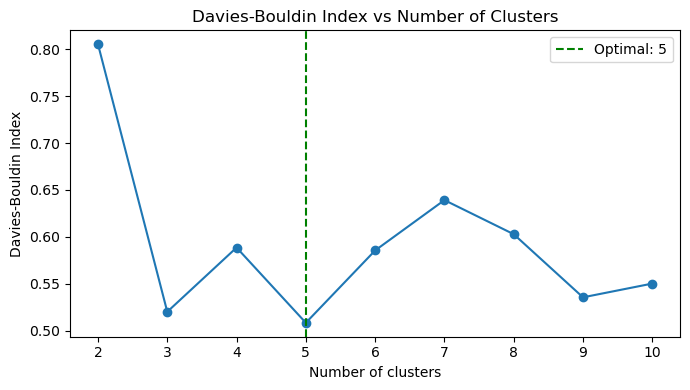

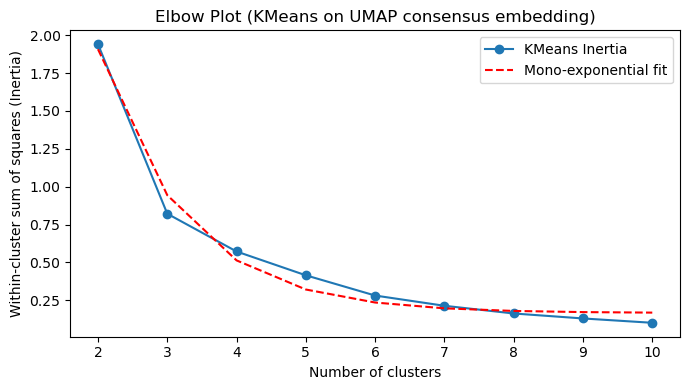

Silhouette score has been choosen, n_clust set to: 5


In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Cluster number selection using multiple validation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Range of cluster numbers to test
cluster_range = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Use hierarchical clustering (Ward) on UMAP embedding for validation
Z_umap = linkage(consensus_embedding, method='ward')

for n_clusters in cluster_range:
    labels = fcluster(Z_umap, n_clusters, criterion='maxclust')
    silhouette_scores.append(silhouette_score(consensus_embedding, labels))
    calinski_scores.append(calinski_harabasz_score(consensus_embedding, labels))
    davies_scores.append(davies_bouldin_score(consensus_embedding, labels))

# Find optimal number of clusters for each metric
optimal_silhouette = cluster_range[np.argmax(silhouette_scores)]
optimal_calinski = cluster_range[np.argmax(calinski_scores)]
optimal_davies = cluster_range[np.argmin(davies_scores)]

# Plot for Silhouette Score
plt.figure(figsize=(7,4))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.axvline(optimal_silhouette, color='blue', linestyle='--', label=f'Optimal: {optimal_silhouette}')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Calinski-Harabasz Index
plt.figure(figsize=(7,4))
plt.plot(cluster_range, calinski_scores, marker='o')
plt.axvline(optimal_calinski, color='orange', linestyle='--', label=f'Optimal: {optimal_calinski}')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Davies-Bouldin Index
plt.figure(figsize=(7,4))
plt.plot(cluster_range, davies_scores, marker='o')
plt.axvline(optimal_davies, color='green', linestyle='--', label=f'Optimal: {optimal_davies}')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Elbow plot using within-cluster sum of squares (inertia) from KMeans
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit

inertias = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(consensus_embedding)
    inertias.append(kmeans.inertia_)

# Fit a mono-exponential decay to the inertia curve
def mono_exp(x, a, b, c):
    return a * np.exp(-b * x) + c

popt, _ = curve_fit(mono_exp, np.array(list(cluster_range)), inertias, maxfev=10000)

plt.figure(figsize=(7,4))
plt.plot(cluster_range, inertias, marker='o', label='KMeans Inertia')
plt.plot(cluster_range, mono_exp(np.array(list(cluster_range)), *popt), 'r--', label='Mono-exponential fit')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Elbow Plot (KMeans on UMAP consensus embedding)')
plt.legend()
plt.tight_layout()
plt.show()

# Set n_clust to the optimal silhouette value (or choose as needed)
#n_clust = optimal_silhouette
n_clust = 5  # Example value, replace with your choice based on the plots
print(f"Silhouette score has been choosen, n_clust set to: {n_clust}")

### OLD - Method selection

Different hierarchical clustering (HC) methods, such as 'ward', 'average', and 'complete', use different strategies to define the distance between clusters. Testing several methods allows us to see which one best separates the data into meaningful groups. The best method is the one that produces clusters that are most consistent with the biological or experimental structure of the data, and that are visually well separated in both the UMAP and PCA projections.  
Here 'ward' seems to give the best clustering, with cluster that are less mixted with their neighbor.

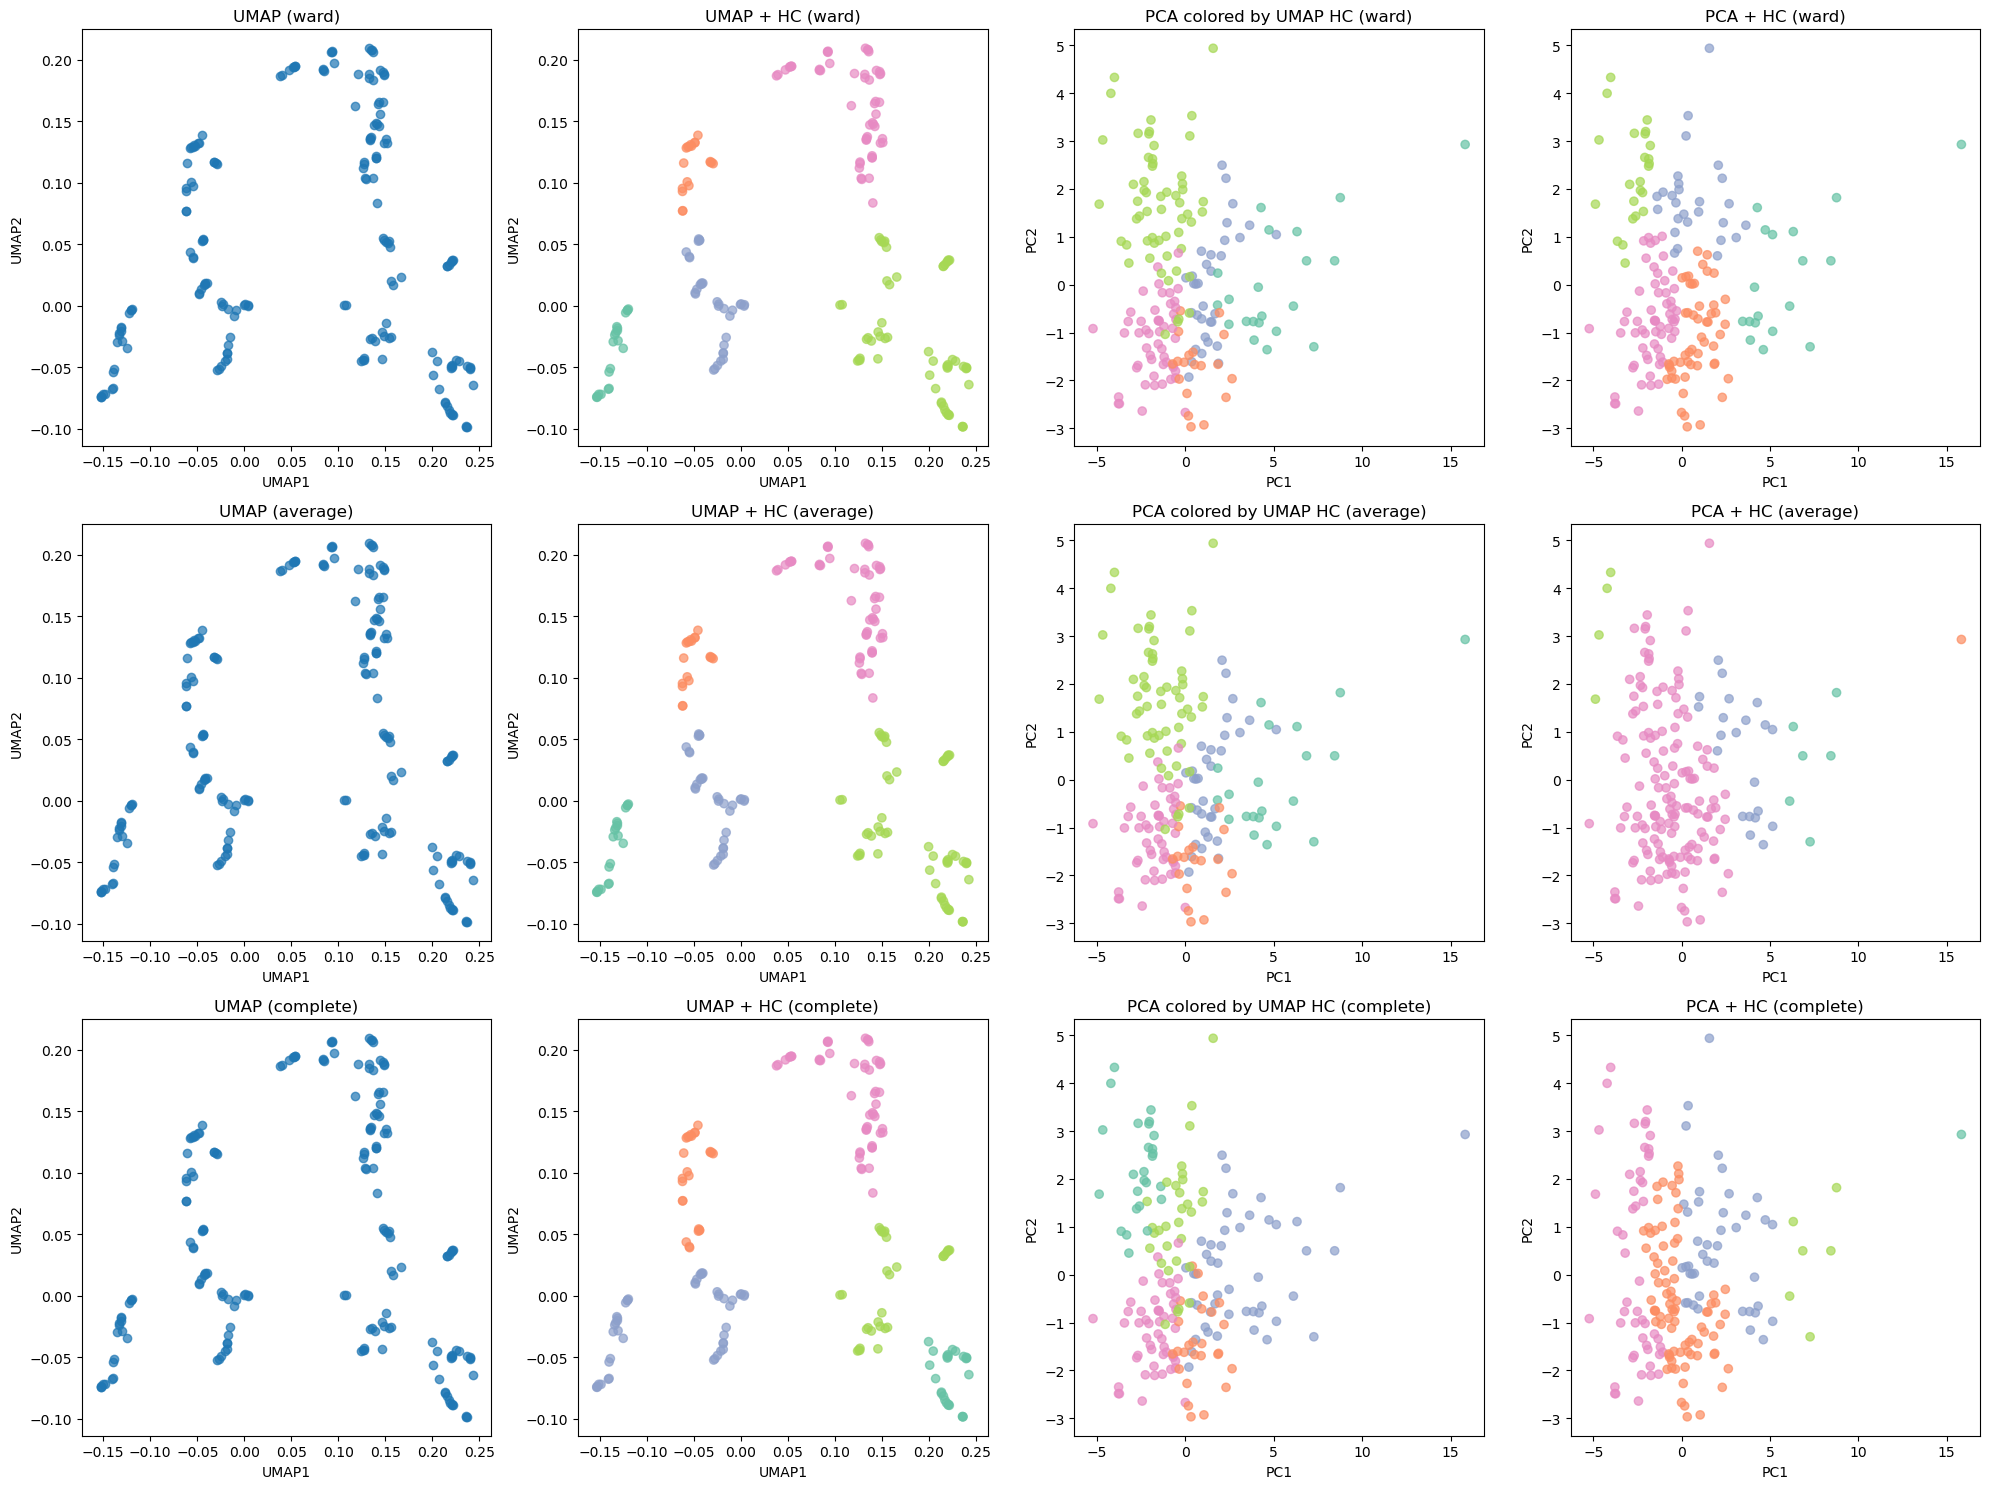

In [17]:
hc_methods = ['ward', 'average', 'complete']
fig, axes = plt.subplots(len(hc_methods), 4, figsize=(20, 5 * len(hc_methods)))
cmap = cm.get_cmap('Set2')

# Use the first method (ward) as reference for consistent colors
reference_method = hc_methods[0]
Z_ref = linkage(consensus_embedding, method=reference_method)
reference_labels = fcluster(Z_ref, n_clust, criterion='maxclust')

for i, method in enumerate(hc_methods):
    # UMAP HC
    Z_umap = linkage(consensus_embedding, method=method)
    hc_labels_umap = fcluster(Z_umap, n_clust, criterion='maxclust')
    
    # Align to reference if not the first method
    if i > 0:
        conf = confusion_matrix(reference_labels, hc_labels_umap)
        row_ind, col_ind = linear_sum_assignment(-conf)
        label_map = {col+1: row+1 for row, col in zip(row_ind, col_ind)}
        hc_labels_umap = np.array([label_map[x] for x in hc_labels_umap])

    # PCA HC
    Z_pca = linkage(transformed_data_WT_pooled, method=method)
    hc_labels_pca = fcluster(Z_pca, n_clust, criterion='maxclust')

    # Align PCA HC to the (now aligned) UMAP HC
    conf = confusion_matrix(hc_labels_umap, hc_labels_pca)
    row_ind, col_ind = linear_sum_assignment(-conf)
    label_map = {col+1: row+1 for row, col in zip(row_ind, col_ind)}
    hc_labels_pca_aligned = np.array([label_map[x] for x in hc_labels_pca])

    # Colors for clusters (now consistent across methods)
    colors_umap = [cmap(l-1) for l in hc_labels_umap]
    colors_pca_hc = [cmap(l-1) for l in hc_labels_pca_aligned]

    # UMAP scatter
    ax_umap = axes[i, 0]
    ax_umap.scatter(consensus_embedding[:, 0], consensus_embedding[:, 1], alpha=0.7)
    ax_umap.set_title(f'UMAP ({method})')
    ax_umap.set_xlabel('UMAP1')
    ax_umap.set_ylabel('UMAP2')

    # UMAP + HC scatter
    ax_umap_hc = axes[i, 1]
    ax_umap_hc.scatter(consensus_embedding[:, 0], consensus_embedding[:, 1], c=colors_umap, alpha=0.7)
    ax_umap_hc.set_title(f'UMAP + HC ({method})')
    ax_umap_hc.set_xlabel('UMAP1')
    ax_umap_hc.set_ylabel('UMAP2')

    # PCA with UMAP HC labels
    ax_pca_hc = axes[i, 2]
    ax_pca_hc.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], c=colors_umap, alpha=0.7)
    ax_pca_hc.set_title(f'PCA colored by UMAP HC ({method})')
    ax_pca_hc.set_xlabel('PC1')
    ax_pca_hc.set_ylabel('PC2')

    # PCA with PCA HC labels (aligned)
    ax_pca_hc2 = axes[i, 3]
    ax_pca_hc2.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], c=colors_pca_hc, alpha=0.7)
    ax_pca_hc2.set_title(f'PCA + HC ({method})')
    ax_pca_hc2.set_xlabel('PC1')
    ax_pca_hc2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### PCA + UMAP based HC + 95% confidence ellipse
Ellipse represent 95% confidence. A chi-square distribution with 2 degrees of freedom is used.

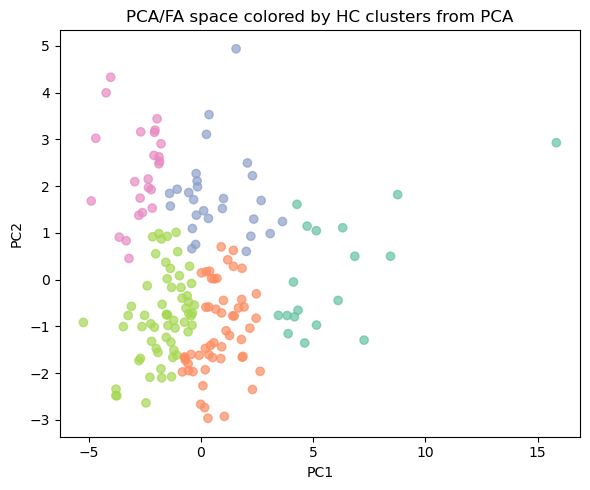

In [18]:
# Perform hierarchical clustering on UMAP embedding
Z = linkage(transformed_data_WT_pooled, method='ward') #/!!!!!!!!!!!!!!!!!\ ICI PASSAGE EN CLUSTERING PCA ET NON UMAP

#Z = linkage(consensus_embedding, method='ward')

hc_labels = fcluster(Z, n_clust, criterion='maxclust')

# Import again the pooled data for WT and add HC labels 
df_WT_poolclust  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="WT_pooled")
df_WT_poolclust['HC_UMAP'] = hc_labels

# Use consistent colormap
cmap = cm.get_cmap('Set2')
colors_umap = [cmap(l-1) for l in hc_labels]

# Project HC cluster labels onto PCA/FA space
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], 
                    c=colors_umap, alpha=0.7)

def draw_ellipse(position, covariance, ax, **kwargs):
    """Draw confidence ellipse for cluster visualization"""
    if covariance.shape == (2, 2):
        # Critical value for 95% confidence with 2 degrees of freedom
        chi2_val = chi2.ppf(0.95, df=2)
        # Singular value decomposition of covariance matrix
        U, s, _ = np.linalg.svd(covariance)
        # Rotation angle of the ellipse
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        # Width and height of the ellipse (principal axes)
        width, height = 2 * np.sqrt(chi2_val * s)
    else:
        # 1D case (shouldn't happen with PC1 and PC2)
        angle = 0
        chi2_val = chi2.ppf(0.95, df=1)
        width, height = 2 * np.sqrt(chi2_val * covariance), 2 * np.sqrt(chi2_val * covariance)
    
    ellipse = Ellipse(position, width, height, angle, **kwargs)
    ax.add_patch(ellipse)

# Add confidence ellipses for each cluster
for cluster_id in range(1, n_clust + 1):
    # Get points belonging to this cluster
    cluster_mask = hc_labels == cluster_id
    cluster_points = transformed_data_WT_pooled[cluster_mask]
    
    if len(cluster_points) > 2:  # Need at least 3 points for covariance
        # Calculate cluster center and covariance
        center = np.mean(cluster_points, axis=0)
        covariance = np.cov(cluster_points.T)
        
        # Draw 95% confidence ellipse
        #draw_ellipse(center, covariance, ax, 
                  #  facecolor=cmap(cluster_id-1), alpha=0.2, 
                  #  edgecolor=cmap(cluster_id-1), linewidth=2)

ax.set_title('PCA/FA space colored by HC clusters from PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()



plt.savefig(os.path.join(output_dir, "PCA_pooled.pdf"))

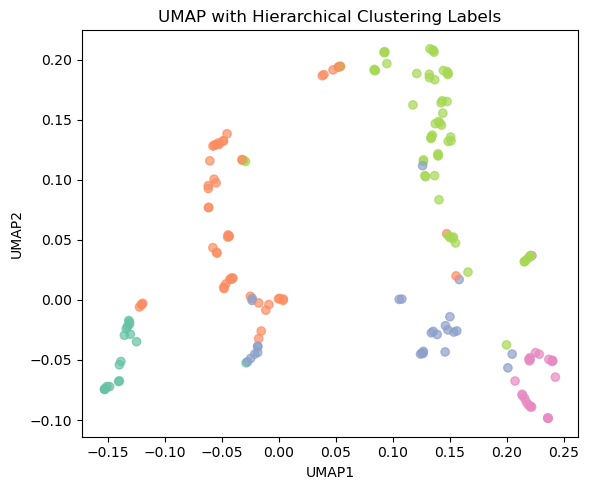

In [19]:
# Plot UMAP with hierarchical clustering labels
plt.figure(figsize=(6, 5))
scatter = plt.scatter(consensus_embedding[:, 0], consensus_embedding[:, 1], 
                    c=colors_umap, alpha=0.7)

plt.title('UMAP with Hierarchical Clustering Labels')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "UMAP_HC_labels.pdf"))
plt.show()

### Dendrogram A CORRGIER

A dendrogram is plotted here to visualize the hierarchical relationships between samples based on their similarity in the consensus UMAP embedding. This tree-like diagram allows us to see how clusters are formed at different levels of similarity, identify distinct groups, and assess the structure and separation of clusters. It provides an intuitive way to explore the results of hierarchical clustering and supports the selection of cluster boundaries for downstream analysis.

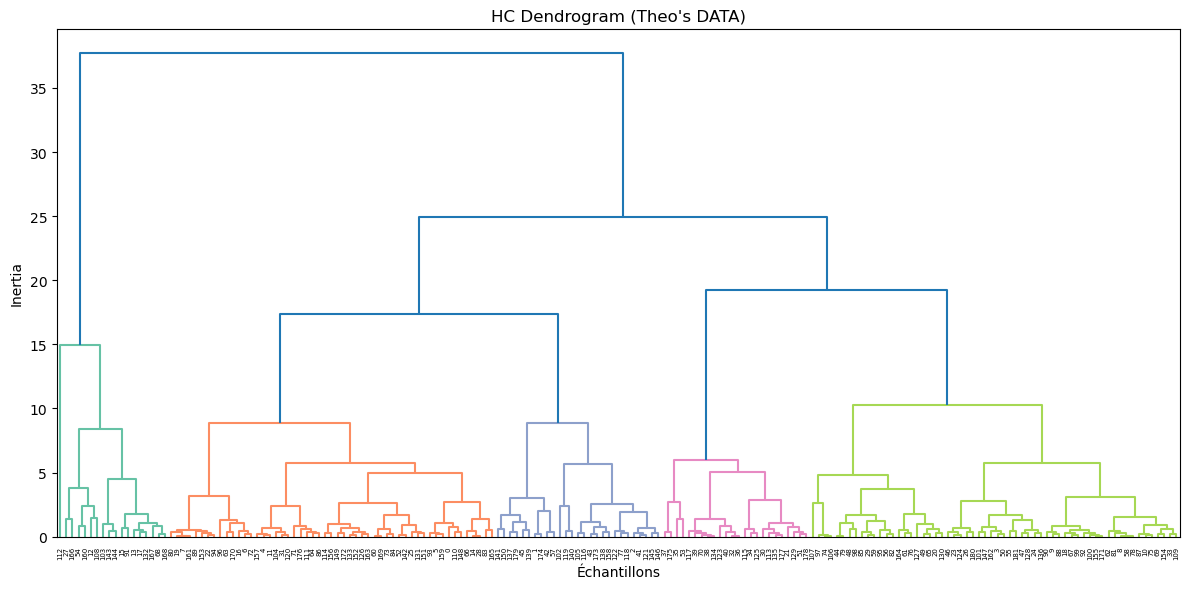

In [20]:
# Use the same colormap and number of clusters as before
cmap = cm.get_cmap('Set2')
hex_colors = [to_hex(cmap(i)) for i in range(n_clust)]
set_link_color_palette(hex_colors)

plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=Z[-n_clust+1, 2], labels=transformed_WT_pooled.index.to_list(), leaf_rotation=90, )
plt.title("HC Dendrogram (Theo's DATA)")
plt.xlabel("Échantillons")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "HC_Dendrogram.pdf"))

### Biplot PCA
A biplot is used here to visualize both the samples and the variable loadings in the principal component space. This allows us to interpret how each original feature contributes to the first two principal components and to see the relationships between variables and samples simultaneously. By plotting the variable vectors, we can identify which features are most influential in separating the data, and how clusters or trends in the data relate to specific experimental measurements. This enhances the interpretability of the PCA results and helps link biological meaning to the observed patterns.


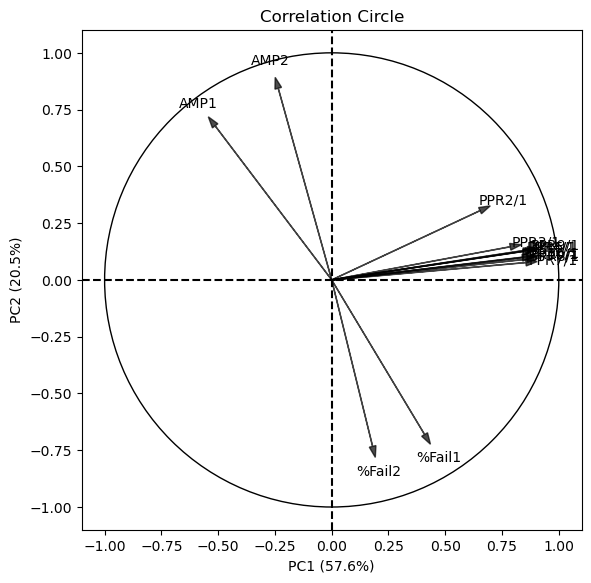

In [21]:
# PCA biplot: Visualize variable contributions to PC1 and PC2
# This uses the PCA object 'reducer' and its components_
# Update biplot to use correlation coefficients instead of loadings
# Get correlation coefficients between PCs and original variables
corr_coef = coeff_corr.T.values
scaling_factor = 1
corr_coef_scaled = corr_coef * scaling_factor

# Create the circle for correlation biplot
circle = plt.Circle((0, 0), 1, color='black', fill=False)
plt.figure(figsize=(6,6))
plt.axhline(0, color='black', linestyle='dashed')
plt.axvline(0, color='black', linestyle='dashed')
plt.gca().add_artist(circle)

# Plot correlation vectors
for i, var in enumerate(df_WT_pooled.columns):
    plt.arrow(0, 0, corr_coef_scaled[i, 0], corr_coef_scaled[i, 1],
              color='black', alpha=0.7, head_width=0.03, head_length=0.05, length_includes_head=True)
    plt.text(corr_coef_scaled[i, 0]*1.08, corr_coef_scaled[i, 1]*1.08, var, ha='center', va='center')

plt.xlabel(f"PC1 ({reducer_PCA.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({reducer_PCA.explained_variance_ratio_[1]*100:.1f}%)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.title('Correlation Circle')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "correlation_circle.pdf"))
plt.show()

# CONTROLE - Projection WT anthime sur PCA.

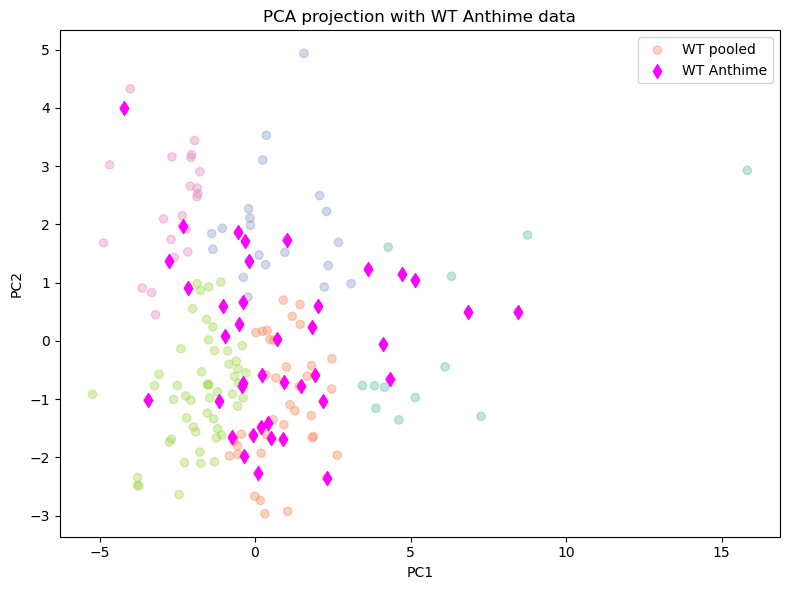

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(transformed_WT_Anthime['PC1'], transformed_WT_Anthime['PC2'], marker='d', s=50, c='magenta', label='WT Anthime')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with WT Anthime data')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_WT_Anthime.pdf"))
plt.show()

## BONUS - PCA with PC/IN projected.

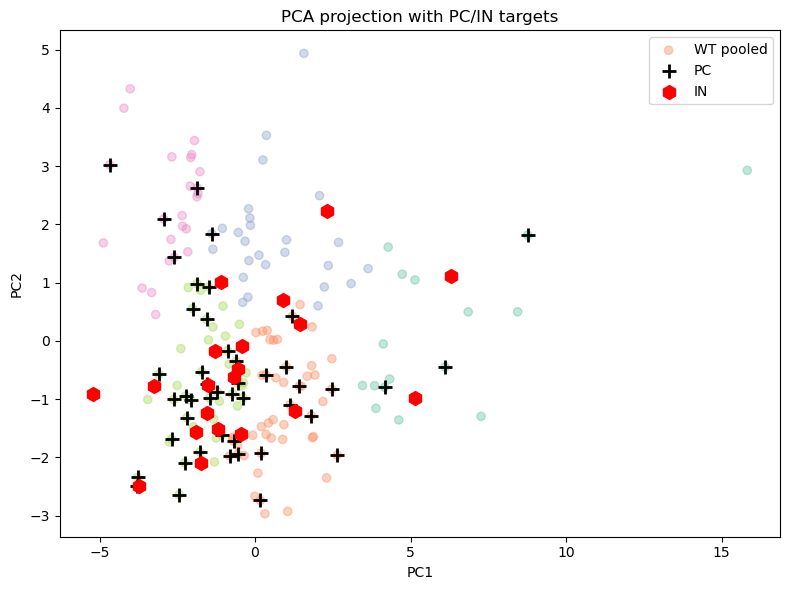

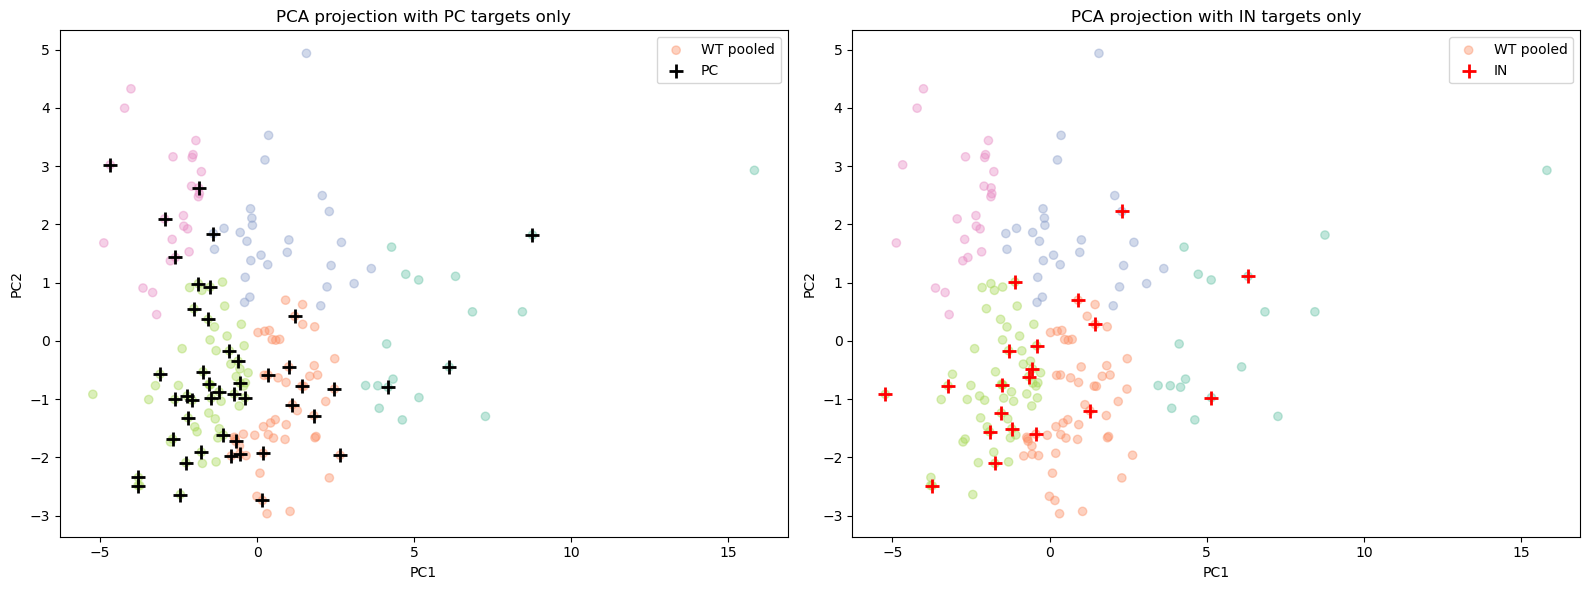

In [23]:
df_WT_Theo    = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="WT_Theo")
# Filter data for PC and IN targets only
pc_data = df_WT_Theo[df_WT_Theo['Target'] == 'PC']
in_data = df_WT_Theo[df_WT_Theo['Target'] == 'IN']

# Get the indices for PC and IN data
pc_indices = pc_data.index
in_indices = in_data.index

# Extract corresponding transformed data
pc_transformed = transformed_data_WT_Theo[pc_indices]
in_transformed = transformed_data_WT_Theo[in_indices]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
plt.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='h', s=100, c='red', label='IN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with PC/IN targets')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_PC_IN.pdf"))
plt.show()
# Separate plots for PC and IN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Only PC targets
ax1.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
ax1.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA projection with PC targets only')
ax1.legend()

# Plot 2: Only IN targets
ax2.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
ax2.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='+', s=100, c='red', linewidths=2, label='IN')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA projection with IN targets only')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_PC_IN_separate.pdf"))
plt.show()


## Bonus - Projection des boutons a grosse amplitude comparé à SynII.

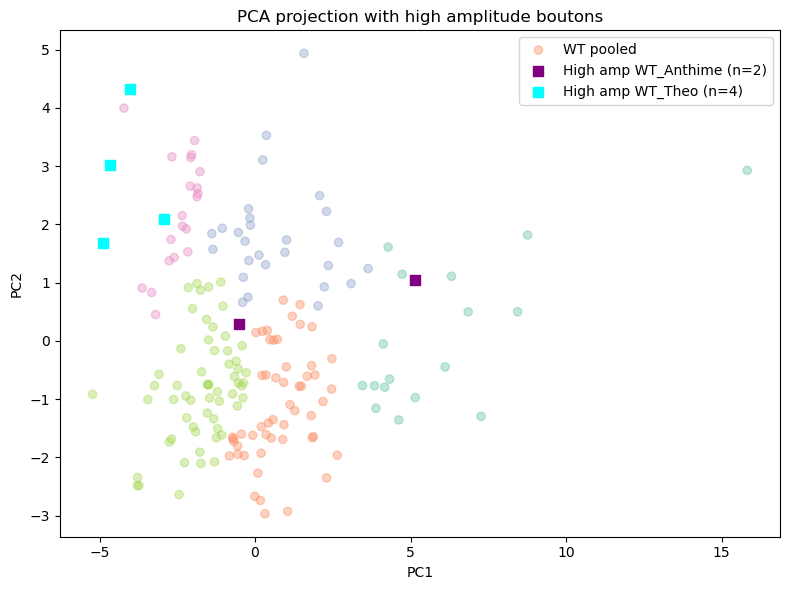

Nombre total de boutons haute amplitude projetés: 6
WT_Anthime: 2 boutons
WT_Theo: 4 boutons


In [24]:
# Get the list of red traces (high amplitude traces) from both WT datasets
red_traces_combined = red_traces_anthime + red_traces_theo

# Extract the corresponding data points from the transformed datasets
high_amp_indices_anthime = []
high_amp_indices_theo = []

# For WT_Anthime - find indices of red traces
for trace_id in red_traces_anthime:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_anthime.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_anthime.append(col_index)

# For WT_Theo - find indices of red traces  
for trace_id in red_traces_theo:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_theo.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_theo.append(col_index)

# Extract the corresponding transformed data points
high_amp_anthime_transformed = transformed_data_WT_Anthime[high_amp_indices_anthime]
high_amp_theo_transformed = transformed_data_WT_Theo[high_amp_indices_theo]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(high_amp_anthime_transformed[:, 0], high_amp_anthime_transformed[:, 1], 
           marker='s', s=50, c='purple', label=f'High amp WT_Anthime (n={len(high_amp_anthime_transformed)})')
plt.scatter(high_amp_theo_transformed[:, 0], high_amp_theo_transformed[:, 1], 
           marker='s', s=50, c='cyan', label=f'High amp WT_Theo (n={len(high_amp_theo_transformed)})')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with high amplitude boutons')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_high_amplitude_boutons.pdf"))
plt.show()

print(f"Nombre total de boutons haute amplitude projetés: {len(high_amp_anthime_transformed) + len(high_amp_theo_transformed)}")
print(f"WT_Anthime: {len(high_amp_anthime_transformed)} boutons")
print(f"WT_Theo: {len(high_amp_theo_transformed)} boutons")

## 5 - Average profile by classes

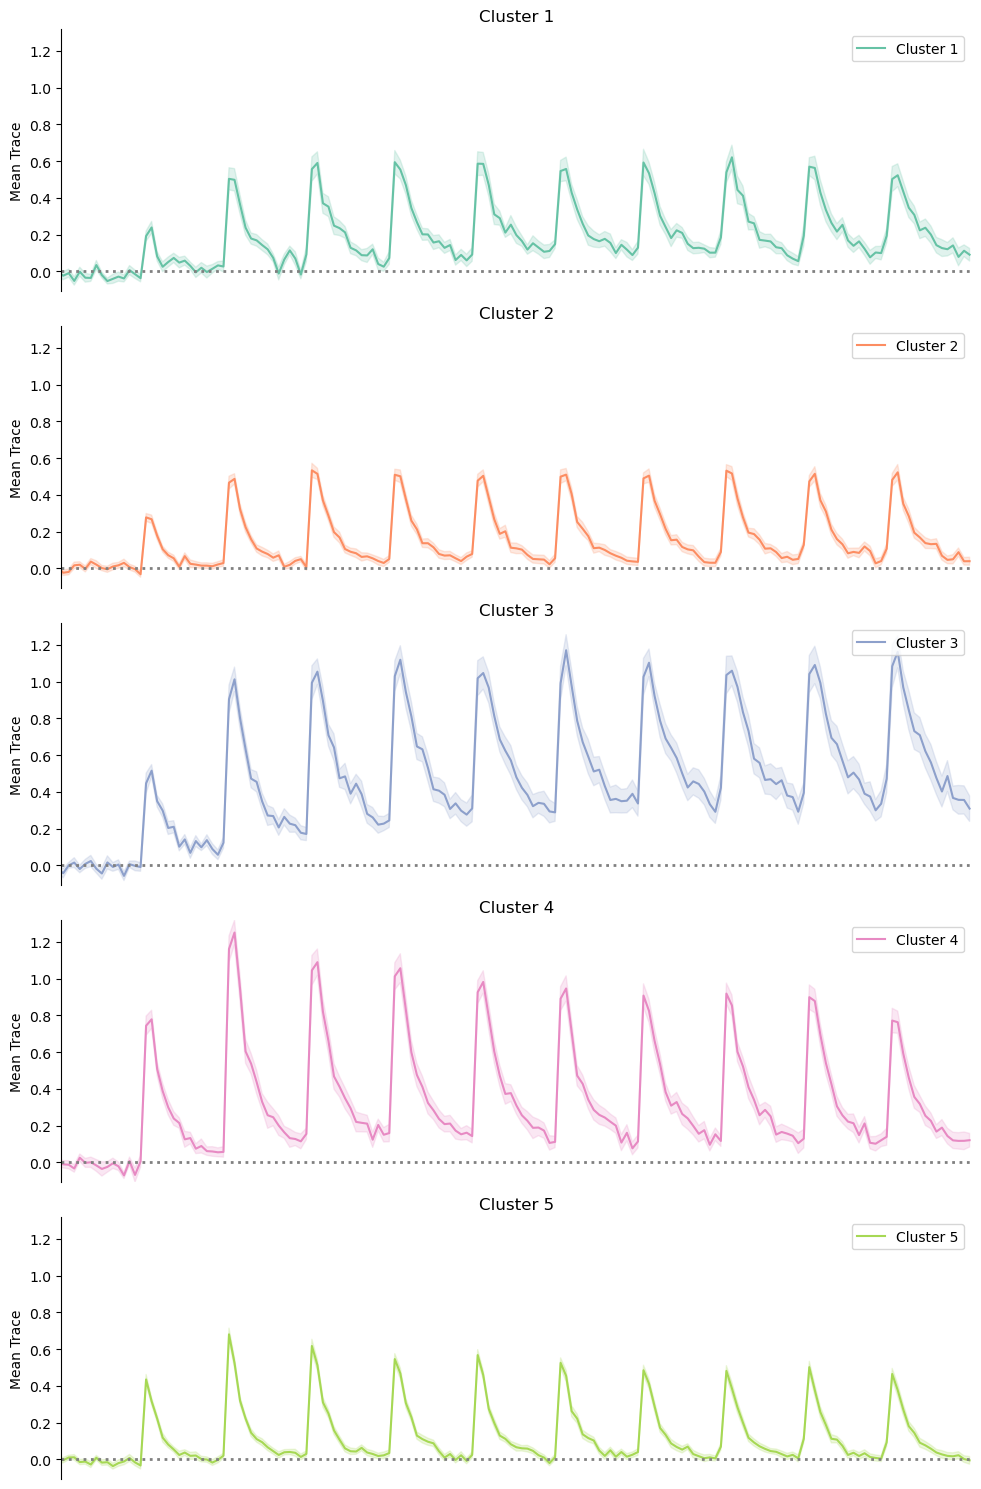

In [68]:
test  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column (ignoring the first row if it's an ID)
time = test.iloc[1:, 0].values
trace_ids = test.columns[1:]

# Associate each ID to its cluster via df_WT_poolclust
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
clusters = sorted(set(id_to_cluster.values()))
cmap = cm.get_cmap('Set2')

# Calculate global y-axis limits across all clusters
all_mean_traces = []
all_sem_traces = []
for cluster in clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        all_mean_traces.extend(mean_trace)
        all_sem_traces.extend(sem_trace)

# Calculate global y-limits
global_min = np.min(np.array(all_mean_traces) - np.array(all_sem_traces))
global_max = np.max(np.array(all_mean_traces) + np.array(all_sem_traces))

# Create a figure with one subplot per cluster
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 3*len(clusters)), sharex=True)

# Verification of IDs associated with each cluster
for cluster in sorted(set(id_to_cluster.values())):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    #print(f"Cluster {cluster}: {cluster_ids}")

plotted = False
for idx, cluster in enumerate(clusters):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        color = cmap(idx)
        axes[idx].plot(time, mean_trace, color=color, label=f'Cluster {cluster}')
        axes[idx].fill_between(time, mean_trace-sem_trace, mean_trace+sem_trace, color=color, alpha=0.2)
        axes[idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[idx].set_ylabel('Mean Trace')
        axes[idx].set_xlim(0.45, 1.0)
        axes[idx].legend(loc='upper right')
        axes[idx].set_title(f'Cluster {cluster}')
        
        # Set consistent y-axis limits for all subplots
        axes[idx].set_ylim(global_min, global_max)
        
        # Remove frame and x-axis
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
        axes[idx].spines['bottom'].set_visible(False)
        axes[idx].get_xaxis().set_visible(False)
        
        plotted = True
    else:
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Traces_clust.pdf"))

if plotted:
    plt.show()
else:
    print('No traces found for any cluster.')



## 6 - Release properties
Here are ploted the different properties of each classes of boutons.
### PPR profiles

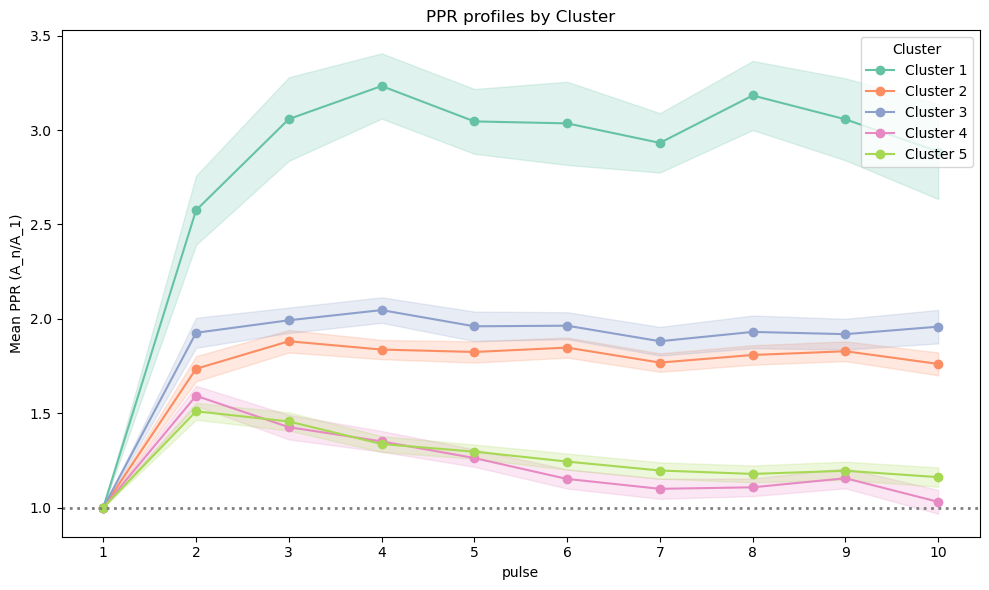

In [26]:
# Plot PPR profiles for each cluster with SEM and custom x-axis, using consistent Set2 colors
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
cmap = cm.get_cmap('Set2')
plt.figure(figsize=(10, 6))
for idx, cluster in enumerate(clusters):
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(idx)
    plt.plot(x_pulses, means, marker='o', label=f'Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles by Cluster')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR_profiles.pdf"))
plt.show()

### PPR2 (A2/A1)

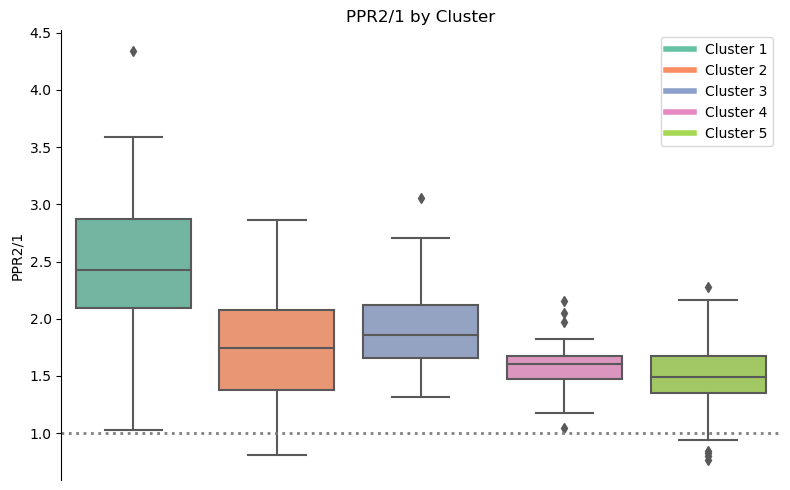

In [27]:
# Create a boxplot for PPR2/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR2/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR2/1')
plt.title('PPR2/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
# Legend with cluster labels
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR2_1.pdf"))

### PPR3 (A3/A1)

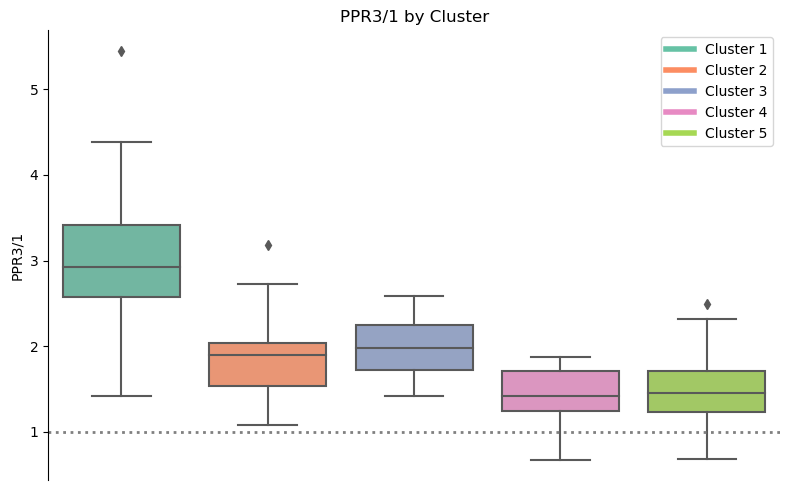

In [28]:
# Create a boxplot for PPR3/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR3/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR3/1')
plt.title('PPR3/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR3_1.pdf"))


### AMP1

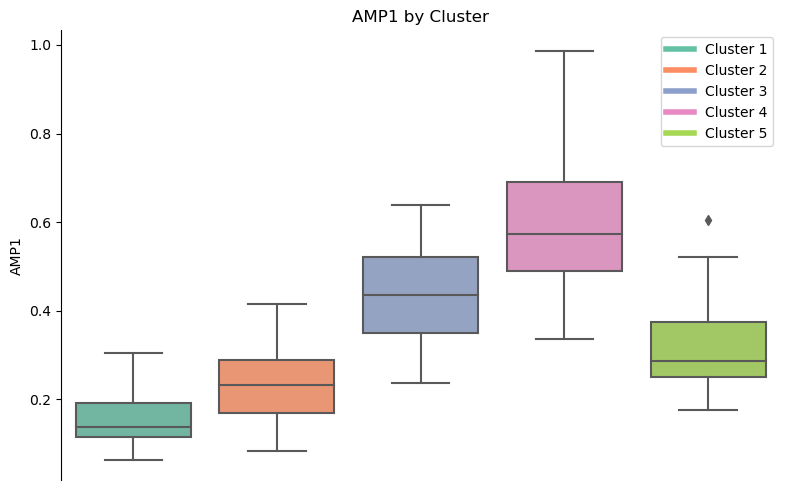

In [29]:
# Create a boxplot for AMP1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='AMP1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('AMP1')
plt.title('AMP1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_AMP1.pdf"))

### %Fail1

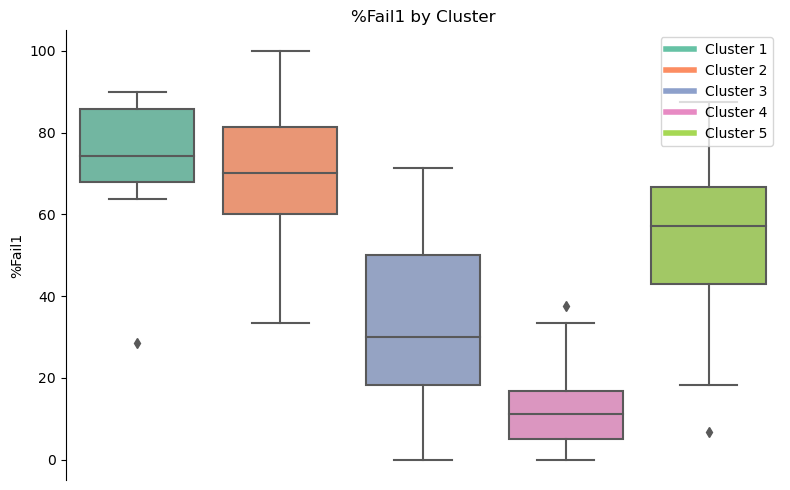

In [30]:
# Create a boxplot for %Fail1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='%Fail1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('%Fail1')
plt.title('%Fail1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_Fail1.pdf"))

# Figure 2 : SynII
## 1 - Projection des données SynII sur la PCA

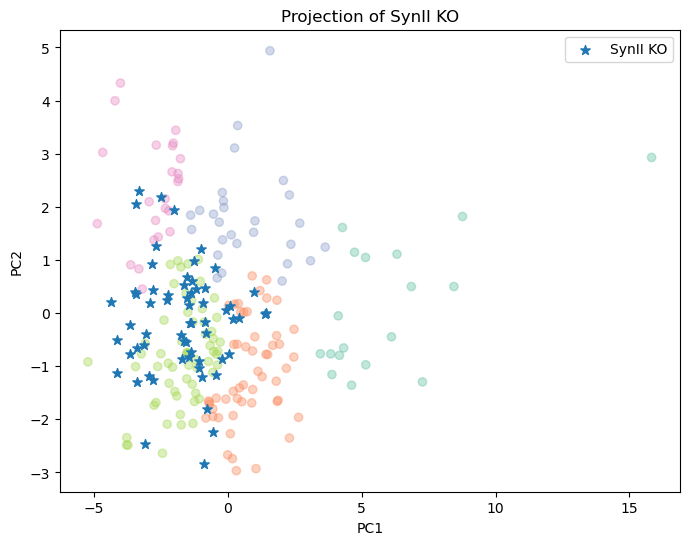

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.4)
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],marker='*', s=50, label='SynII KO')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection of SynII KO')
plt.legend()
plt.show
plt.savefig(os.path.join(output_dir, "PCA_synII.pdf"))

# 2 - Proportion de SynII dans les clusters WT
## Proportion of SynII in WT Clusters

This analysis explores the distribution of SynII knockout data points across the clusters previously identified in wild-type (WT) samples. 

The visualization in the previous cell reveals that SynII knockout boutons have a distinct distribution pattern among the five functional classes identified in WT boutons. This suggests that the absence of Synapsin II alters specific aspects of synaptic transmission, potentially affecting some functional clusters more than others.

The bar chart compares the percentage of boutons belonging to each cluster between WT and SynII samples, highlighting shifts in the functional profile caused by the Synapsin II knockout. This comparison helps identify which specific functional classes of synaptic transmission are most affected by the loss of Synapsin II.

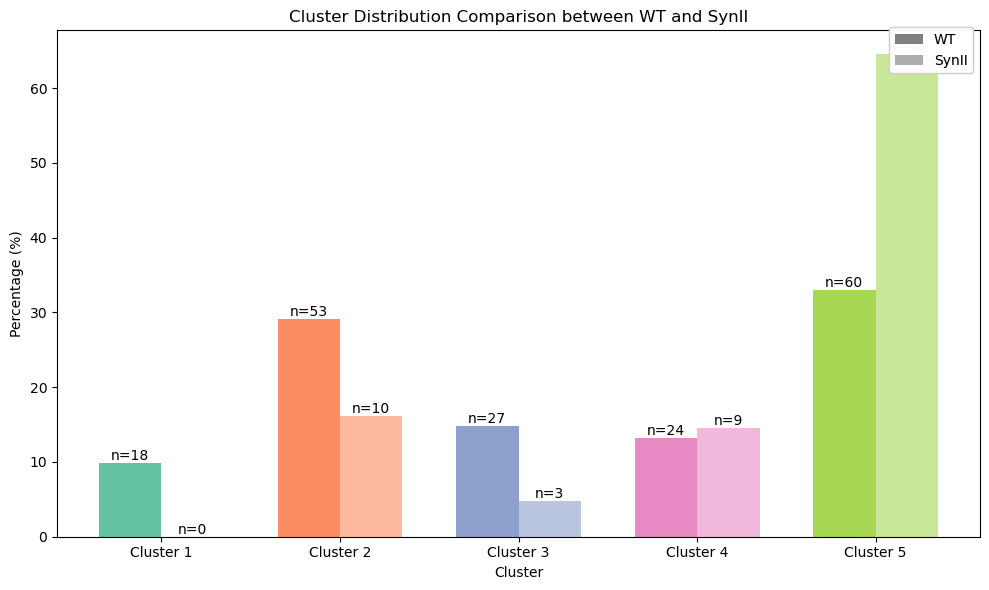

Cluster distribution in WT samples:
Cluster 1: 9.9% (n=18)
Cluster 2: 29.1% (n=53)
Cluster 3: 14.8% (n=27)
Cluster 4: 13.2% (n=24)
Cluster 5: 33.0% (n=60)

Cluster distribution in SynII samples:
Cluster 1: 0.0% (n=0)
Cluster 2: 16.1% (n=10)
Cluster 3: 4.8% (n=3)
Cluster 4: 14.5% (n=9)
Cluster 5: 64.5% (n=40)


In [32]:
# Function to assign new data to existing clusters based on proximity to centroids
def assign_clusters_hcpc(X_ref_scaled, clusters_ref, X_target_scaled):
    # Calculate centroids of reference clusters
    centroids = np.array([X_ref_scaled[clusters_ref == i].mean(axis=0) for i in np.unique(clusters_ref)])
    assigned = []
    for x in X_target_scaled:
        # Find closest centroid
        dist = np.linalg.norm(centroids - x, axis=1)
        assigned.append(np.argmin(dist) + 1)  # +1 because clusters are 1-indexed
    return np.array(assigned)

# Assign SynII data to WT clusters
clusters_SynII = assign_clusters_hcpc(transformed_data_WT_pooled, hc_labels, transformed_data_SynII)

# Calculate counts and percentages for both datasets
wt_counts = pd.Series(hc_labels).value_counts().sort_index()
wt_counts = pd.DataFrame({
    'Cluster': wt_counts.index,
    'Count': wt_counts.values,
    'Percentage': 100 * wt_counts.values / len(hc_labels),
    'Dataset': 'WT'
})

# Ensure all clusters are represented in synii_counts
all_clusters = range(1, n_clust + 1)
synii_counts_series = pd.Series(clusters_SynII).value_counts()
synii_counts = pd.DataFrame({
    'Cluster': all_clusters,
    'Count': [synii_counts_series.get(c, 0) for c in all_clusters],
    'Percentage': [100 * synii_counts_series.get(c, 0) / len(clusters_SynII) for c in all_clusters],
    'Dataset': 'SynII'
})
synii_counts = synii_counts.sort_values('Cluster').reset_index(drop=True)

# Create figure and axis objects
plt.figure(figsize=(10, 6))

# Create color palette for clusters using Set2
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)
cluster_colors = [cmap(i) for i in range(n_clusters)]

# Setup for grouped bar plot
bar_width = 0.35
x = np.arange(n_clusters)

# Plot WT bars - solid colors
bars_wt = plt.bar(x - bar_width/2, wt_counts['Percentage'], bar_width,
                  label='WT', color=cluster_colors)

# Plot SynII bars - same colors but transparent
bars_synii = plt.bar(x + bar_width/2, synii_counts['Percentage'], bar_width,
                     label='SynII', color=cluster_colors, alpha=0.6)

# Add count labels on the bars
for bars, counts in [(bars_wt, wt_counts), (bars_synii, synii_counts)]:
    for bar, count in zip(bars, counts['Count']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'n={int(count)}',
                ha='center', va='bottom')

plt.title('Cluster Distribution Comparison between WT and SynII')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(x, [f'Cluster {i}' for i in wt_counts['Cluster']])

# Add dataset type legend
wt_patch = plt.Rectangle((0,0),1,1, fc='gray')
synii_patch = plt.Rectangle((0,0),1,1, fc='gray', alpha=0.6)
l1 = plt.legend([wt_patch, synii_patch], ['WT', 'SynII'], 
                loc='upper right', bbox_to_anchor=(1, 1.02))
plt.gca().add_artist(l1)


plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_SynII_cluster_comparison.pdf"))
plt.show()

# Print the distribution summary
print("Cluster distribution in WT samples:")
for i, row in wt_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")

print("\nCluster distribution in SynII samples:")
for i, row in synii_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")


### Other representation

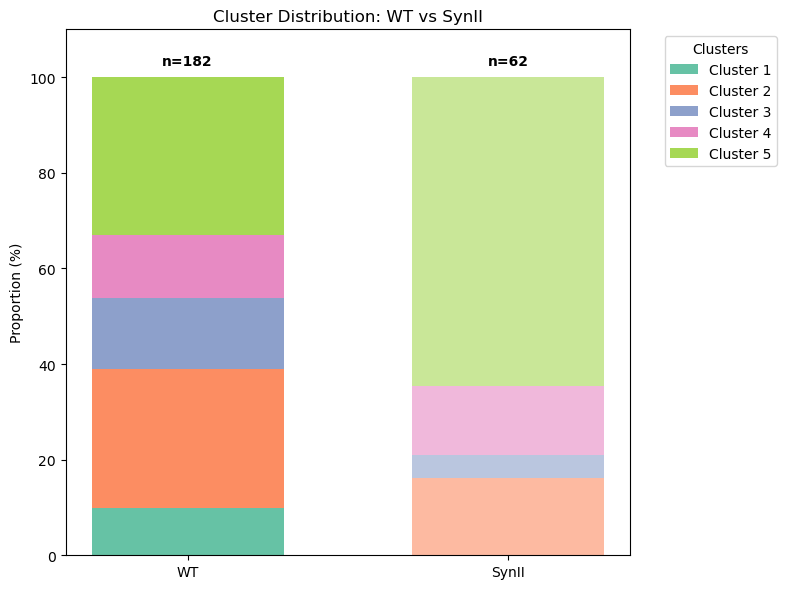

In [33]:
# Create a normalized stacked bar plot showing proportion of each cluster within WT and SynII
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate proportions for each dataset
wt_proportions = wt_counts['Percentage'].values
synii_proportions = synii_counts['Percentage'].values

# Create stacked bars for WT and SynII
datasets = ['WT', 'SynII']
proportions = [wt_proportions, synii_proportions]
bar_width = 0.6

# Use Set2 colormap for clusters
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)

# Create stacked bars
bottom_wt = 0
bottom_synii = 0

for i in range(n_clusters):
    cluster_color = cmap(i)
    
    # WT bar
    ax.bar(0, wt_proportions[i], bar_width, bottom=bottom_wt, 
           color=cluster_color, label=f'Cluster {i+1}')
    bottom_wt += wt_proportions[i]
    
    # SynII bar
    ax.bar(1, synii_proportions[i], bar_width, bottom=bottom_synii, 
           color=cluster_color, alpha=0.6)
    bottom_synii += synii_proportions[i]

# Add count labels on bars
for i, (dataset, counts) in enumerate(zip(['WT', 'SynII'], [wt_counts, synii_counts])):
    total_count = counts['Count'].sum()
    ax.text(i, 102, f'n={total_count}', ha='center', va='bottom', fontweight='bold')

# Customize plot
ax.set_ylabel('Proportion (%)')
ax.set_title('Cluster Distribution: WT vs SynII')
ax.set_xticks([0, 1])
ax.set_xticklabels(['WT', 'SynII'])
ax.set_ylim(0, 110)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "stacked_bar_WT_SynII_normalized.pdf"))
plt.show()

## 3 - Means values of the different parameters

In [34]:
# Calculate mean ± SD for Amp1, Amp2, and %Fail1 in SynII data
print("Mean ± SD for SynII data:")
print(f"AMP1: {df_SynII['AMP1'].mean():.3f} ± {df_SynII['AMP1'].std():.3f}")
print(f"AMP2: {df_SynII['AMP2'].mean():.3f} ± {df_SynII['AMP2'].std():.3f}")
print(f"%Fail1: {df_SynII['%Fail1'].mean():.3f} ± {df_SynII['%Fail1'].std():.3f}")

Mean ± SD for SynII data:
AMP1: 0.333 ± 0.140
AMP2: 0.454 ± 0.172
%Fail1: 37.238 ± 23.874


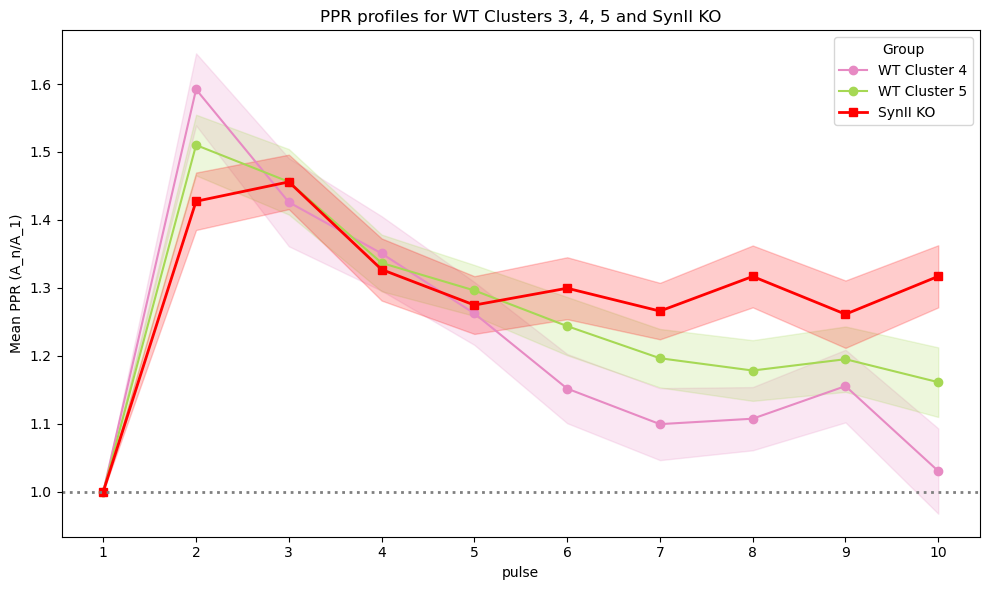

In [65]:
# Plot PPR profiles for clusters 3, 4, and 5 only
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
selected_clusters = [4, 5]
cmap = cm.get_cmap('Set2')

plt.figure(figsize=(10, 6))

# Plot WT clusters 3, 4, and 5
for cluster in selected_clusters:
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(cluster-1)  # Use cluster-1 for proper color indexing
    plt.plot(x_pulses, means, marker='o', label=f'WT Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)

# Add SynII data
synii_means = [1] + df_SynII[ppr_cols].mean().tolist()  # pulse 1 is always 1
synii_sems = [0] + df_SynII[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
plt.plot(x_pulses, synii_means, marker='s', label='SynII KO', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(synii_means)-np.array(synii_sems), np.array(synii_means)+np.array(synii_sems), alpha=0.2, color='red')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles for WT Clusters 3, 4, 5 and SynII KO')
plt.legend(title='Group', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_345_SynII_PPR_profiles.pdf"))
plt.show()

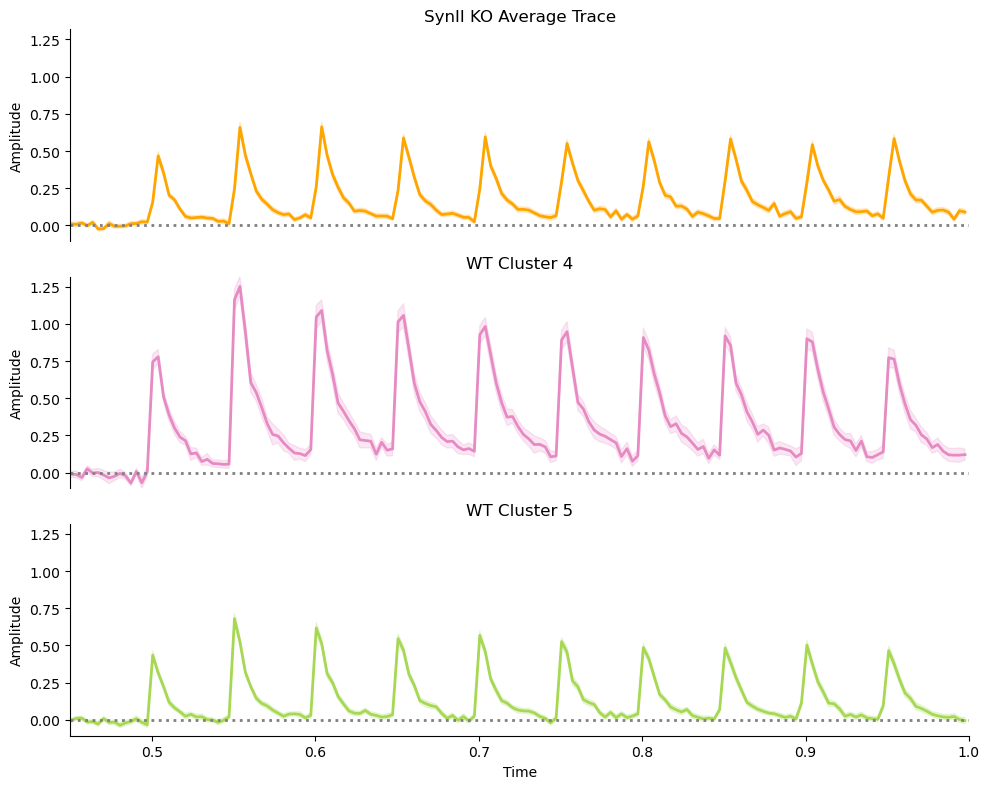

In [69]:
# Load SynII trace data
test_SynII = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=0)
test_wt = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column
time = test_SynII.iloc[1:, 0].values

# SynII traces
synii_trace_data = test_SynII.iloc[1:, 1:].astype(float).values
synii_mean_trace = np.mean(synii_trace_data, axis=1)
synii_sem_trace = np.std(synii_trace_data, axis=1) / np.sqrt(synii_trace_data.shape[1])

# Calculate peak amplitude for purple line (between 0.5s and 0.53s)
mask_peak = (time >= 0.5) & (time <= 0.53)
peak_amp_individual = synii_trace_data[mask_peak, :].max()

# WT cluster traces
trace_ids = test_wt.columns[1:]
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
selected_clusters = [4, 5]
cmap = cm.get_cmap('Set2')

# Calculate cluster traces
cluster_traces = {}
for cluster in selected_clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test_wt.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        cluster_traces[cluster] = {'mean': mean_trace, 'sem': sem_trace}

# Calculate global y-limits for consistent scaling
all_means = [synii_mean_trace]
all_sems = [synii_sem_trace]
for cluster_data in cluster_traces.values():
    all_means.append(cluster_data['mean'])
    all_sems.append(cluster_data['sem'])

all_means_flat = np.concatenate(all_means)
all_sems_flat = np.concatenate(all_sems)
global_min = np.min(all_means_flat - all_sems_flat)
global_max = np.max(all_means_flat + all_sems_flat)

# Create subplots: SynII on top, WT clusters below
fig, axes = plt.subplots(len(selected_clusters) + 1, 1, figsize=(10, 8), sharex=True)

# Plot SynII trace (top subplot)
axes[0].plot(time, synii_mean_trace, color='orange', linewidth=2, label='SynII KO')
axes[0].fill_between(time, synii_mean_trace-synii_sem_trace, synii_mean_trace+synii_sem_trace, 
                     color='orange', alpha=0.2)
axes[0].axhline(0, color='gray', linestyle='dotted', linewidth=2)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('SynII KO Average Trace')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_ylim(global_min, global_max)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].get_xaxis().set_visible(False)

# Plot WT cluster traces (bottom subplots)
for idx, cluster in enumerate(selected_clusters):
    ax_idx = idx + 1
    if cluster in cluster_traces:
        cluster_data = cluster_traces[cluster]
        color = cmap(cluster-1)
        axes[ax_idx].plot(time, cluster_data['mean'], color=color, linewidth=2, 
                         label=f'WT Cluster {cluster}')
        axes[ax_idx].fill_between(time, cluster_data['mean']-cluster_data['sem'], 
                                 cluster_data['mean']+cluster_data['sem'], 
                                 color=color, alpha=0.2)
        axes[ax_idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[ax_idx].set_ylabel('Amplitude')
        axes[ax_idx].set_title(f'WT Cluster {cluster}')
        axes[ax_idx].set_xlim(0.45, 1.0)
        axes[ax_idx].set_ylim(global_min, global_max)
        axes[ax_idx].spines['top'].set_visible(False)
        axes[ax_idx].spines['right'].set_visible(False)
        
        # Only show x-axis on the last subplot
        if idx < len(selected_clusters) - 1:
            axes[ax_idx].spines['bottom'].set_visible(False)
            axes[ax_idx].get_xaxis().set_visible(False)
        else:
            axes[ax_idx].set_xlabel('Time')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "SynII_vs_WT_clusters_345_traces.pdf"))
plt.show()

# Figure 3 : Diversité sur une même fibre
## 1 - Barplot of the proportion of PFs displaying 1 to 4 classes of boutons

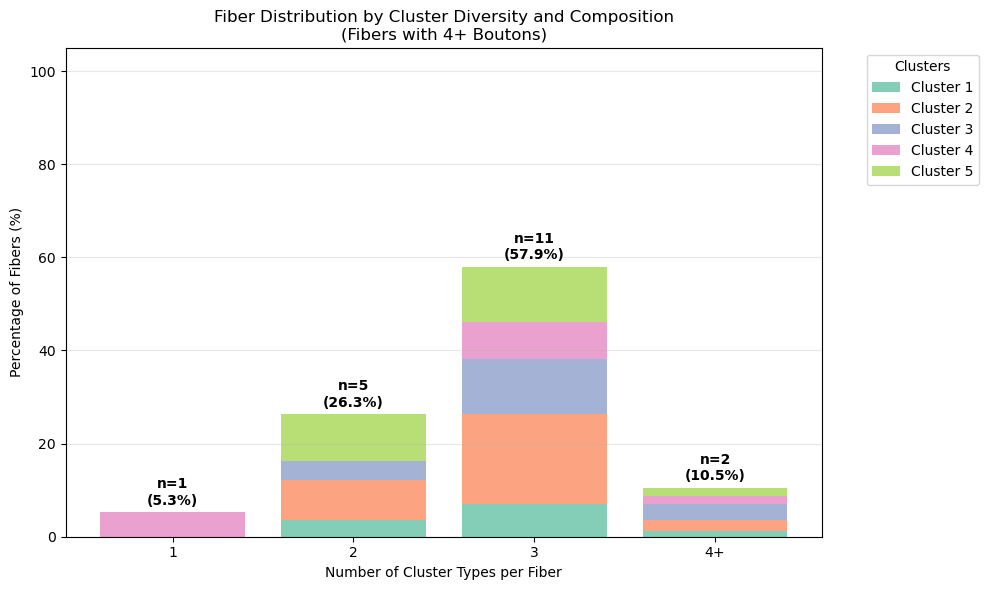

Fiber cluster diversity composition summary (fibers with 4+ boutons only):

Fibers with 1 cluster type(s): 1 fibers (5.3%)
  Cluster 4: 100.0% average proportion (1.0 fiber-equivalents)

Fibers with 2 cluster type(s): 5 fibers (26.3%)
  Cluster 1: 13.3% average proportion (0.7 fiber-equivalents)
  Cluster 2: 32.7% average proportion (1.6 fiber-equivalents)
  Cluster 3: 16.0% average proportion (0.8 fiber-equivalents)
  Cluster 5: 38.0% average proportion (1.9 fiber-equivalents)

Fibers with 3 cluster type(s): 11 fibers (57.9%)
  Cluster 1: 12.2% average proportion (1.3 fiber-equivalents)
  Cluster 2: 33.1% average proportion (3.6 fiber-equivalents)
  Cluster 3: 20.6% average proportion (2.3 fiber-equivalents)
  Cluster 4: 13.6% average proportion (1.5 fiber-equivalents)
  Cluster 5: 20.4% average proportion (2.2 fiber-equivalents)

Fibers with 4+ cluster type(s): 2 fibers (10.5%)
  Cluster 1: 11.1% average proportion (0.2 fiber-equivalents)
  Cluster 2: 22.2% average proportion (0.4 fi

In [39]:
# Extract fiber ID from the full ID (first 22 characters)
df_WT_poolclust['Fiber_ID'] = df_WT_poolclust['ID'].str[:22]

# Count total number of boutons per fiber
fiber_bouton_counts = df_WT_poolclust.groupby('Fiber_ID').size().reset_index(name='Bouton_Count')

# Filter to keep only fibers with 4 or more boutons
fibers_with_enough_boutons = fiber_bouton_counts[fiber_bouton_counts['Bouton_Count'] >= 4]['Fiber_ID'].tolist()
df_filtered = df_WT_poolclust[df_WT_poolclust['Fiber_ID'].isin(fibers_with_enough_boutons)]

# Count number of different clusters per fiber
fiber_cluster_diversity = df_filtered.groupby('Fiber_ID')['HC_UMAP'].nunique().reset_index()
fiber_cluster_diversity.columns = ['Fiber_ID', 'Num_Cluster_Types']

# Add bouton count information
fiber_cluster_diversity = fiber_cluster_diversity.merge(
    fiber_bouton_counts, on='Fiber_ID', how='left'
)

# Categorize fibers by number of cluster types (cap at 4+)
fiber_cluster_diversity['Cluster_Diversity'] = fiber_cluster_diversity['Num_Cluster_Types'].apply(
    lambda x: f'{x}' if x <= 3 else '4+'
)

# Calculate cluster distribution for each diversity category
diversity_cluster_data = {}
for fiber_id in df_filtered['Fiber_ID'].unique():
    fiber_data = df_filtered[df_filtered['Fiber_ID'] == fiber_id]
    num_clusters = len(fiber_data['HC_UMAP'].unique())
    diversity_key = str(num_clusters) if num_clusters <= 3 else '4+'
    
    if diversity_key not in diversity_cluster_data:
        diversity_cluster_data[diversity_key] = []
    
    # Count clusters for this fiber
    cluster_counts = fiber_data['HC_UMAP'].value_counts()
    total_boutons = len(fiber_data)
    cluster_props = {cluster: count/total_boutons for cluster, count in cluster_counts.items()}
    diversity_cluster_data[diversity_key].append(cluster_props)

# Calculate average proportions and absolute counts for each cluster in each diversity category
diversity_order = ['1', '2', '3', '4+']
cmap = cm.get_cmap('Set2')
n_clusters_total = 5  # Total number of clusters

# Calculate mean proportions and fiber counts
diversity_means = {}
diversity_counts = {}
total_fibers = len(fiber_cluster_diversity)

for diversity in diversity_order:
    if diversity in diversity_cluster_data:
        diversity_counts[diversity] = len(diversity_cluster_data[diversity])
        cluster_means = {}
        for cluster in range(1, n_clusters_total + 1):
            proportions = [fiber_data.get(cluster, 0) for fiber_data in diversity_cluster_data[diversity]]
            cluster_means[cluster] = np.mean(proportions)
        diversity_means[diversity] = cluster_means
    else:
        diversity_counts[diversity] = 0
        diversity_means[diversity] = {cluster: 0 for cluster in range(1, n_clusters_total + 1)}

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(diversity_order))
bottom = np.zeros(len(diversity_order))

# Create stacked bars with cluster colors - height = percentage of fibers * proportion
for cluster in range(1, n_clusters_total + 1):
    # Calculate percentage values: (number of fibers / total fibers) * 100 * proportion of that cluster
    percentage_values = [(diversity_counts[div] / total_fibers) * 100 * diversity_means[div][cluster] for div in diversity_order]
    bars = ax.bar(x_positions, percentage_values, bottom=bottom, 
                  color=cmap(cluster-1), label=f'Cluster {cluster}', alpha=0.8)
    bottom += percentage_values

# Add count and percentage labels on top of bars
for i, (diversity, count) in enumerate(zip(diversity_order, [diversity_counts[d] for d in diversity_order])):
    percentage_total = (count / total_fibers) * 100
    ax.text(i, percentage_total + 1, f'n={count}\n({percentage_total:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Number of Cluster Types per Fiber')
ax.set_ylabel('Percentage of Fibers (%)')
ax.set_title('Fiber Distribution by Cluster Diversity and Composition\n(Fibers with 4+ Boutons)')
ax.set_xticks(x_positions)
ax.set_xticklabels(diversity_order)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Set y-axis to start at 0 and go to 100%
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fiber_cluster_diversity_composition_4plus_boutons.pdf"))
plt.show()

# Print detailed summary statistics
print("Fiber cluster diversity composition summary (fibers with 4+ boutons only):")
for diversity in diversity_order:
    if diversity in diversity_counts and diversity_counts[diversity] > 0:
        percentage_of_total = (diversity_counts[diversity] / total_fibers) * 100
        print(f"\nFibers with {diversity} cluster type(s): {diversity_counts[diversity]} fibers ({percentage_of_total:.1f}%)")
        for cluster in range(1, n_clusters_total + 1):
            prop = diversity_means[diversity][cluster]
            if prop > 0:
                absolute_count = diversity_counts[diversity] * prop
                print(f"  Cluster {cluster}: {prop:.1%} average proportion ({absolute_count:.1f} fiber-equivalents)")

print(f"\nTotal number of fibers analyzed: {total_fibers}")
print(f"(filtered from {len(fiber_bouton_counts)} total fibers)")

# Calculate average number of boutons per fiber in the filtered dataset
avg_boutons = fiber_cluster_diversity['Bouton_Count'].mean()
print(f"Average boutons per fiber in filtered dataset: {avg_boutons:.1f}")

# Print list of fibers with exactly 3 cluster types
fibers_with_3_clusters = fiber_cluster_diversity[fiber_cluster_diversity['Num_Cluster_Types'] == 3]['Fiber_ID'].tolist()
print(f"\nList of fibers with exactly 3 cluster types ({len(fibers_with_3_clusters)} fibers):")
for fiber_id in fibers_with_3_clusters:
    print(f"  {fiber_id}")

## 2 - Potential SynII fibers vs potential non-SynII fibers

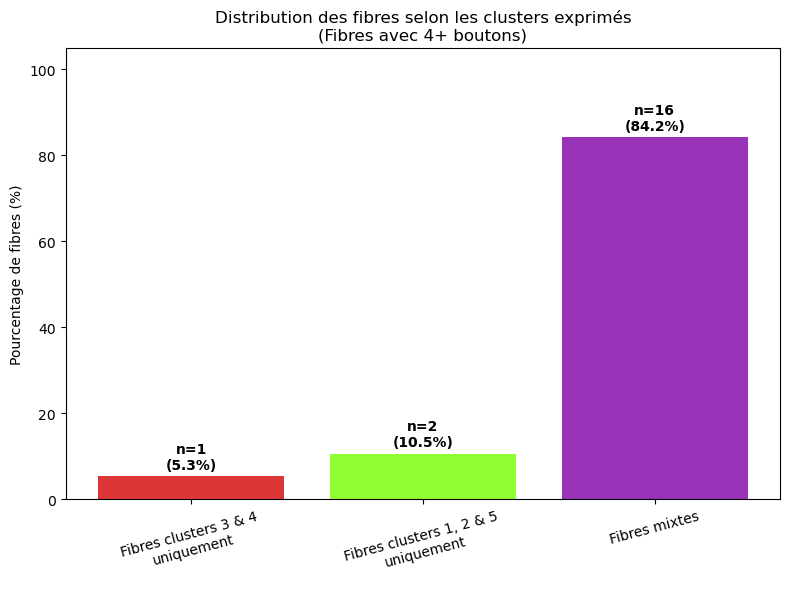

Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):
- Fibres exprimant uniquement les clusters 3 et/ou 4: 1 fibres (5.3%)
- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: 2 fibres (10.5%)
- Fibres mixtes (combinaison des deux groupes): 16 fibres (84.2%)
- Total: 19 fibres (avec 4+ boutons)

Exemples de fibres mixtes (si il y en a):
  20220426_linescan2_20H: clusters [3, 4, 5]
  241212_Fibre1_PortionD: clusters [1, 2, 5]
  20190801_linescan1_20H: clusters [2, 3, 5]
  20220414_linescan1_20H: clusters [2, 3, 4]
  20210310_linescan1_20H: clusters [2, 5]
  ... et 11 autres fibres mixtes

Détail des fibres clusters 3 & 4 uniquement:
  20210128_linescan4_20H: clusters [4]

Détail des fibres clusters 1, 2 & 5 uniquement:
  20201015_linescan4_20H: clusters [1, 2]
  20210310_linescan4_20H: clusters [1, 2, 3]


In [40]:
# Classification des fibres selon les clusters exprimés
# Utiliser seulement les fibres avec 4+ boutons (comme dans l'analyse précédente)
fibers_clusters = df_filtered.groupby('Fiber_ID')['HC_UMAP'].apply(lambda x: set(x.unique()))

# Fibres n'exprimant QUE les clusters 3 et/ou 4 (aucun autre cluster)
fibers_only_3_4 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({4, 5}) and len(s) > 0)]

# Fibres n'exprimant QUE les clusters 1, 2 et/ou 5 (aucun autre cluster)
fibers_only_1_2_5 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({1, 2, 3}) and len(s) > 0)]

# Comptage
count_only_3_4 = len(fibers_only_3_4)
count_only_1_2_5 = len(fibers_only_1_2_5)

# Fibres mixtes (contenant des clusters des deux groupes)
all_fiber_ids = set(fibers_clusters.index)
exclusive_fiber_ids = set(fibers_only_3_4.index) | set(fibers_only_1_2_5.index)
mixed_fibers = all_fiber_ids - exclusive_fiber_ids
count_mixed = len(mixed_fibers)

# Calcul des pourcentages
total_fibers_filtered = len(fibers_clusters)
percentage_3_4 = (count_only_3_4 / total_fibers_filtered) * 100
percentage_1_2_5 = (count_only_1_2_5 / total_fibers_filtered) * 100
percentage_mixed = (count_mixed / total_fibers_filtered) * 100

# Création de l'histogramme avec 3 catégories
labels = ['Fibres clusters 3 & 4\nuniquement', 'Fibres clusters 1, 2 & 5\nuniquement', 'Fibres mixtes']
counts = [count_only_3_4, count_only_1_2_5, count_mixed]
percentages = [percentage_3_4, percentage_1_2_5, percentage_mixed]


plt.figure(figsize=(8,6))
bars = plt.bar(labels, percentages, color=["#d40404", "#73ff00", "#8000a7"], alpha=0.8)
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, pct + 1, 
             f'n={count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Pourcentage de fibres (%)')
plt.title('Distribution des fibres selon les clusters exprimés\n(Fibres avec 4+ boutons)')
plt.xticks(rotation=15)
plt.ylim(0, 105)  # Limiter l'axe Y de 0 à 105%
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fiber_distribution_by_cluster_type.pdf"))
plt.show()

# Affichage des statistiques détaillées
print(f"Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):")
print(f"- Fibres exprimant uniquement les clusters 3 et/ou 4: {count_only_3_4} fibres ({percentage_3_4:.1f}%)")
print(f"- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: {count_only_1_2_5} fibres ({percentage_1_2_5:.1f}%)")
print(f"- Fibres mixtes (combinaison des deux groupes): {count_mixed} fibres ({percentage_mixed:.1f}%)")
print(f"- Total: {total_fibers_filtered} fibres (avec 4+ boutons)")

# Vérification que toutes les fibres sont bien comptées
assert count_only_3_4 + count_only_1_2_5 + count_mixed == total_fibers_filtered, "Erreur: toutes les fibres ne sont pas comptées"

print(f"\nExemples de fibres mixtes (si il y en a):")
if count_mixed > 0:
    for i, fiber_id in enumerate(list(mixed_fibers)[:5]):  # Afficher les 5 premières
        clusters_in_fiber = list(fibers_clusters[fiber_id])
        print(f"  {fiber_id}: clusters {clusters_in_fiber}")
    if count_mixed > 5:
        print(f"  ... et {count_mixed - 5} autres fibres mixtes")
else:
    print("  Aucune fibre mixte détectée")

# Affichage détaillé des fibres de chaque catégorie
print(f"\nDétail des fibres clusters 3 & 4 uniquement:")
for fiber_id in fibers_only_3_4.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

print(f"\nDétail des fibres clusters 1, 2 & 5 uniquement:")
for fiber_id in fibers_only_1_2_5.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

# Chaines de boutons.

Pour voir la répartition des boutons d'une même fibre dans les clusters.

In [41]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np

# Function to extract fiber ID based on dataset
def get_fiber_id(full_id, dataset_type):
    if dataset_type == 'SynII':
        return full_id[:13]
    elif dataset_type == 'WT_Anthime':
        return full_id[:22]
    elif dataset_type == 'WT_Theo':
        return full_id[:18]
    else:
        return full_id

# Combine all datasets with their types
all_data = []

# Add SynII data
for i, synii_id in enumerate(test_SynII.columns[1:]):  # Skip time column
    if i < transformed_data_SynII.shape[0]:  # Check bounds
        all_data.append({
            'ID': synii_id,
            'PC1': transformed_data_SynII[i, 0],
            'PC2': transformed_data_SynII[i, 1],
            'dataset': 'SynII',
            'fiber_id': get_fiber_id(synii_id, 'SynII'),
            'color': 'orange',
            'marker': '*'
        })

# Add WT_Anthime data
for i, anthime_id in enumerate(test_wt_anthime.columns[1:]):  # Skip time column
    if i < transformed_data_WT_Anthime.shape[0]:  # Check bounds
        all_data.append({
            'ID': anthime_id,
            'PC1': transformed_data_WT_Anthime[i, 0],
            'PC2': transformed_data_WT_Anthime[i, 1],
            'dataset': 'WT_Anthime',
            'fiber_id': get_fiber_id(anthime_id, 'WT_Anthime'),
            'color': 'lightgreen',
            'marker': 's'
        })

# Add WT_Theo data
for i, theo_id in enumerate(test_wt_theo.columns[1:]):  # Skip time column
    if i < transformed_data_WT_Theo.shape[0]:  # Check bounds
        all_data.append({
            'ID': theo_id,
            'PC1': transformed_data_WT_Theo[i, 0],
            'PC2': transformed_data_WT_Theo[i, 1],
            'dataset': 'WT_Theo',
            'fiber_id': get_fiber_id(theo_id, 'WT_Theo'),
            'color': 'blue',
            'marker': 'o'
        })

# Group by fiber ID
fibers = {}
for data_point in all_data:
    fiber_id = data_point['fiber_id']
    if fiber_id not in fibers:
        fibers[fiber_id] = []
    fibers[fiber_id].append(data_point)

# Filter fibers with more than 1 bouton
fibers_multi = {k: v for k, v in fibers.items() if len(v) > 1}
fiber_list = list(fibers_multi.keys())

print(f"Found {len(fiber_list)} fibers with multiple boutons")

# Create interactive plot
class FiberNavigator:
    def __init__(self, fibers_dict, fiber_list):
        self.fibers = fibers_dict
        self.fiber_list = fiber_list
        self.current_index = 0
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(12, 8))
        self.fig.subplots_adjust(bottom=0.2)
        
        # Add navigation buttons
        ax_prev = plt.axes([0.3, 0.05, 0.1, 0.075])
        ax_next = plt.axes([0.6, 0.05, 0.1, 0.075])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_fiber)
        self.btn_next.on_clicked(self.next_fiber)
        
        # Connect keyboard events
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # Initial plot
        self.update_plot()
        
    def prev_fiber(self, event=None):
        if self.current_index > 0:
            self.current_index -= 1
            self.update_plot()
    
    def next_fiber(self, event=None):
        if self.current_index < len(self.fiber_list) - 1:
            self.current_index += 1
            self.update_plot()
    
    def on_key_press(self, event):
        if event.key == 'left':
            self.prev_fiber()
        elif event.key == 'right':
            self.next_fiber()
    
    def update_plot(self):
        self.ax.clear()
        
        # Plot background PCA data (WT pooled)
        self.ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], 
                       c=colors_umap, alpha=0.3, s=30, label='WT pooled background')
        
        # Get current fiber data
        current_fiber_id = self.fiber_list[self.current_index]
        current_fiber_data = self.fibers[current_fiber_id]
        
        # Sort boutons by ID to maintain order along the fiber
        current_fiber_data.sort(key=lambda x: x['ID'])
        
        # Extract coordinates
        x_coords = [point['PC1'] for point in current_fiber_data]
        y_coords = [point['PC2'] for point in current_fiber_data]
        
        # Plot connection lines
        self.ax.plot(x_coords, y_coords, 'r-', linewidth=2, alpha=0.8, label='Fiber connection')
        
        # Plot boutons with numbers
        for i, point in enumerate(current_fiber_data):
            self.ax.scatter(point['PC1'], point['PC2'], 
                           c=point['color'], marker=point['marker'], 
                           s=100, edgecolor='black', linewidth=1, zorder=5)
            
            # Add number annotation
            self.ax.annotate(str(i+1), (point['PC1'], point['PC2']), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=10, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Set labels and title
        self.ax.set_xlabel('PC1')
        self.ax.set_ylabel('PC2')
        self.ax.set_title(f'Fiber {self.current_index + 1}/{len(self.fiber_list)}: {current_fiber_id}\n'
                         f'Dataset: {current_fiber_data[0]["dataset"]} | '
                         f'Boutons: {len(current_fiber_data)}')
        
        # Add legend
        self.ax.legend(loc='upper right')
        
        # Add navigation info
        self.fig.suptitle('Use LEFT/RIGHT arrows or buttons to navigate between fibers', 
                         fontsize=12, y=0.95)
        
        # Refresh plot
        self.fig.canvas.draw()

# Create and show the navigator in a new window
if len(fiber_list) > 0:
    # Force matplotlib to use a GUI backend for interactive window
    import matplotlib
    matplotlib.use('Qt5Agg')  # or 'TkAgg' if Qt5Agg is not available
    
    navigator = FiberNavigator(fibers_multi, fiber_list)
    
    # Set window title (handle different backends)
    try:
        # For Qt5Agg backend
        navigator.fig.canvas.manager.set_window_title("Fiber Navigator - Interactive Bouton Visualization")
    except AttributeError:
        try:
            # Alternative for other backends
            navigator.fig.canvas.manager.window.setWindowTitle("Fiber Navigator - Interactive Bouton Visualization")
        except AttributeError:
            # If neither works, just continue without setting title
            print("Window title could not be set, but the interactive window will still work")
    
    # Show the figure in a new window
    navigator.fig.show()
    
    # Keep the window open
    plt.show(block=True)
else:
    print("No fibers with multiple boutons found")

Found 55 fibers with multiple boutons


In [48]:
# Fix matplotlib backend to enable figure display
import matplotlib
import matplotlib.pyplot as plt
import warnings

# Set matplotlib to use a GUI backend that can display figures
matplotlib.use('Qt5Agg')  # Use Qt5Agg backend for interactive display

# Configure matplotlib for notebook display
%matplotlib inline

# Re-enable interactive mode and clear warnings
plt.ion()
plt.close('all')
plt.rcdefaults()
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

print("✓ Matplotlib backend configured for figure display")
print(f"✓ Current backend: {matplotlib.get_backend()}")
print("✓ Figures should now display properly in the notebook")

✓ Matplotlib backend configured for figure display
✓ Current backend: module://matplotlib_inline.backend_inline
✓ Figures should now display properly in the notebook


# Neighbor Distance Analysis on Fibers

This analysis examines the spatial organization of synaptic boutons along individual parallel fibers by comparing distances between neighboring boutons in both original and scrambled fiber assignments. The goal is to determine whether the observed spatial patterns represent true biological organization or could arise from random assignment of boutons to fibers.

## Methodology

**Fiber ID Extraction**: For each bouton, we extract the fiber ID from the bouton identifier:
- WT data: First 22 characters of the ID
- SynII data: First 13 characters of the ID

**Neighbor Distance Calculation**: For each fiber containing multiple boutons, we calculate the Euclidean distances between consecutive boutons along that fiber in the 2D PCA space. Only consecutive boutons on the same fiber are considered neighbors.

**Fiber Assignment Scrambling**: To establish a null hypothesis, we randomly shuffle the bouton IDs while preserving the original fiber structure (number of boutons per fiber). This destroys the spatial relationships along fibers while maintaining the overall distribution of fiber sizes.

**Statistical Analysis**: The code generates:
- **Histograms**: Comparing probability density distributions of neighbor distances
- **Boxplots**: Comparing medians and quartiles with statistical annotations
- **Multiple comparison tests**: Paired t-tests, Kolmogorov-Smirnov tests, and Kruskal-Wallis tests with Bonferroni correction

**Data Groups Analyzed**:
- WT original vs scrambled fiber assignments
- SynII original vs scrambled fiber assignments  
- Combined (WT + SynII) original vs scrambled assignments

## Expected Results

If spatial organization along fibers represents genuine biological structure, we expect:
- **Shorter neighbor distances**: Original data should show closer spacing between consecutive boutons on the same fiber compared to scrambled assignments
- **Statistical significance**: Significant differences in distance distributions between original and scrambled data
- **Genotype-specific patterns**: WT and SynII may exhibit distinct spatial organization patterns

The statistical tests quantify whether observed differences are significant, helping distinguish true biological spatial organization from random arrangements.

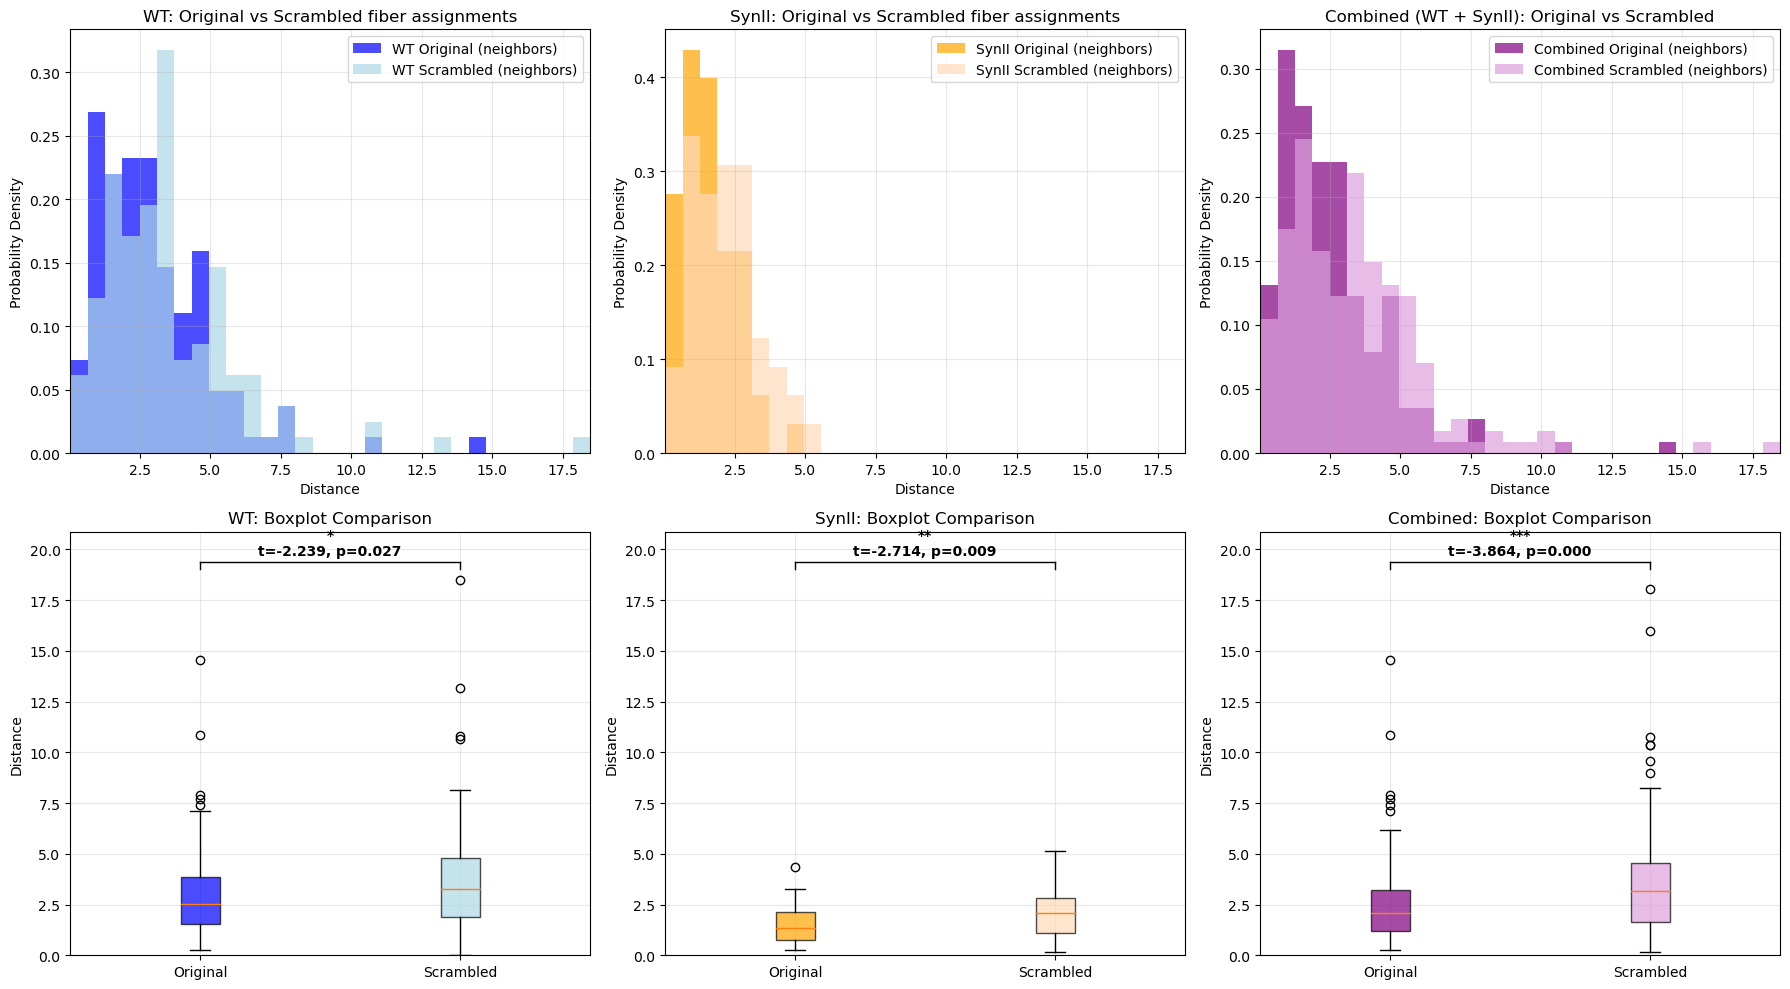

Summary Statistics:
WT Original (neighbors) - Mean: 2.925, Std: 2.068, n=133
WT Scrambled (neighbors) - Mean: 3.580, Std: 2.534, n=133
SynII Original (neighbors) - Mean: 1.542734734680197, Std: 0.9251933788940961, n=53
SynII Scrambled (neighbors) - Mean: 2.138, Std: 1.186, n=53
Combined Original (neighbors) - Mean: 2.531, Std: 1.921, n=186
Combined Scrambled (neighbors) - Mean: 3.414, Std: 2.534, n=186

Kolmogorov-Smirnov tests:
WT Original vs Scrambled: KS=0.188, p=0.018021
SynII Original vs Scrambled: KS=0.264, p=0.049129
Combined Original vs Scrambled: KS=0.253, p=0.000013

Kruskal-Wallis tests with pairwise comparisons (Bonferroni corrected):
WT Original vs Scrambled (Kruskal-Wallis): H=6.311, p=0.012001
SynII Original vs Scrambled (Kruskal-Wallis): H=6.761, p=0.009319
Combined Original vs Scrambled (Kruskal-Wallis): H=16.004, p=0.000063

Pairwise Kruskal-Wallis comparisons (Bonferroni α = 0.003333):
WT_Original vs WT_Scrambled: H=6.311, p=0.012001 ns
WT_Original vs SynII_Original:

In [73]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from scipy import stats

import matplotlib.pyplot as plt

# Function to calculate distances between neighboring boutons on same fiber
def calculate_neighbor_distances_on_fibers(data, fiber_info):
    """Calculate distances between neighboring boutons on the same fiber"""
    neighbor_distances = []
    
    for fiber_id, bouton_indices in fiber_info.items():
        if len(bouton_indices) > 1:  # Need at least 2 boutons per fiber
            # Sort indices to maintain order along fiber
            sorted_indices = sorted(bouton_indices)
            
            # Calculate distances between consecutive boutons on this fiber
            for i in range(len(sorted_indices) - 1):
                idx1, idx2 = sorted_indices[i], sorted_indices[i + 1]
                dist = np.linalg.norm(data[idx1] - data[idx2])
                neighbor_distances.append(dist)
    
    return np.array(neighbor_distances)

# Function to calculate mean pairwise distances for each bouton (for scrambled data)
def calculate_mean_pairwise_distances(data):
    """Calculate mean pairwise distance for each point in the dataset"""
    distances = pdist(data, metric='euclidean')
    distance_matrix = squareform(distances)
    # For each point, calculate mean distance to all other points
    mean_distances = np.mean(distance_matrix, axis=1)
    return mean_distances

# Function to scramble fiber assignments by shuffling IDs
def scramble_fiber_assignments(bouton_ids, original_fiber_info):
    """Scramble fiber assignments by shuffling bouton IDs while keeping fiber structure"""
    # Create a shuffled copy of bouton IDs
    shuffled_ids = bouton_ids.copy()
    np.random.shuffle(shuffled_ids)
    
    # Create new fiber info with shuffled assignments
    scrambled_fiber_info = {}
    for i, shuffled_id in enumerate(shuffled_ids):
        # Extract fiber ID from the shuffled ID (keeping original fiber structure)
        if len(shuffled_id) >= 22:  # WT data
            fiber_id = shuffled_id[:22]
        else:  # SynII data
            fiber_id = shuffled_id[:13]
            
        if fiber_id not in scrambled_fiber_info:
            scrambled_fiber_info[fiber_id] = []
        scrambled_fiber_info[fiber_id].append(i)
    
    return scrambled_fiber_info

# Set random seed for reproducibility
np.random.seed(42)

# Create fiber information for WT data
def create_fiber_info_wt(data_ids):
    """Create fiber information mapping for WT data"""
    fiber_info = {}
    for i, bouton_id in enumerate(data_ids):
        fiber_id = bouton_id[:22]  # Extract fiber ID (first 22 characters)
        if fiber_id not in fiber_info:
            fiber_info[fiber_id] = []
        fiber_info[fiber_id].append(i)
    return fiber_info

# Create fiber information for SynII data  
def create_fiber_info_synii(data_ids):
    """Create fiber information mapping for SynII data"""
    fiber_info = {}
    for i, bouton_id in enumerate(data_ids):
        fiber_id = bouton_id[:13]  # Extract fiber ID (first 13 characters for SynII)
        if fiber_id not in fiber_info:
            fiber_info[fiber_id] = []
        fiber_info[fiber_id].append(i)
    return fiber_info

# Get bouton IDs for each dataset
wt_bouton_ids = df_WT_poolclust['ID'].tolist()

# For SynII, we need to get the actual bouton IDs from the original dataframe
df_SynII_with_id = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime_FINAL.xlsx', sheet_name="SynII")
synii_bouton_ids = df_SynII_with_id['ID'].tolist()

# Create fiber mappings
wt_fiber_info = create_fiber_info_wt(wt_bouton_ids)
synii_fiber_info = create_fiber_info_synii(synii_bouton_ids)

# Calculate neighbor distances for original data (same fiber only)
wt_distances = calculate_neighbor_distances_on_fibers(transformed_data_WT_pooled, wt_fiber_info)
synii_distances = calculate_neighbor_distances_on_fibers(transformed_data_SynII, synii_fiber_info)

# Calculate neighbor distances for scrambled fiber assignments
wt_scrambled_fiber_info = scramble_fiber_assignments(wt_bouton_ids, wt_fiber_info)
synii_scrambled_fiber_info = scramble_fiber_assignments(synii_bouton_ids, synii_fiber_info)
wt_distances_scrambled = calculate_neighbor_distances_on_fibers(transformed_data_WT_pooled, wt_scrambled_fiber_info)
synii_distances_scrambled = calculate_neighbor_distances_on_fibers(transformed_data_SynII, synii_scrambled_fiber_info)

# Combine all data (WT + SynII) for mixed analysis
all_data_combined = np.vstack([transformed_data_WT_pooled, transformed_data_SynII])
all_ids_combined = wt_bouton_ids + synii_bouton_ids

# Create combined fiber info
combined_fiber_info = {}
for i, bouton_id in enumerate(all_ids_combined):
    if len(bouton_id) >= 22:  # WT data
        fiber_id = bouton_id[:22]
    else:  # SynII data
        fiber_id = bouton_id[:13]
    
    if fiber_id not in combined_fiber_info:
        combined_fiber_info[fiber_id] = []
    combined_fiber_info[fiber_id].append(i)

# Calculate distances for combined data
combined_distances = calculate_neighbor_distances_on_fibers(all_data_combined, combined_fiber_info)

# Calculate distances for scrambled combined data
combined_scrambled_fiber_info = scramble_fiber_assignments(all_ids_combined, combined_fiber_info)
combined_distances_scrambled = calculate_neighbor_distances_on_fibers(all_data_combined, combined_scrambled_fiber_info)

# Create the plot with histograms and boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Calculate global x-axis limits for consistency
all_distances = np.concatenate([
    wt_distances, wt_distances_scrambled,
    synii_distances_scrambled,  # Always include scrambled SynII
    combined_distances, combined_distances_scrambled
])
if len(synii_distances) > 0:
    all_distances = np.concatenate([all_distances, synii_distances])

x_min = np.min(all_distances)
x_max = np.max(all_distances)

# Create uniform bins for all histograms
bins = np.linspace(x_min, x_max, 31)  # 30 bins with consistent edges

# Top row: Histograms
# Plot 1: WT original vs scrambled
axes[0,0].hist(wt_distances, bins=bins, alpha=0.7, label='WT Original (neighbors)', color='blue', density=True)
axes[0,0].hist(wt_distances_scrambled, bins=bins, alpha=0.7, label='WT Scrambled (neighbors)', color='lightblue', density=True)
axes[0,0].set_xlabel('Distance')
axes[0,0].set_ylabel('Probability Density')
axes[0,0].set_title('WT: Original vs Scrambled fiber assignments')
axes[0,0].set_xlim(x_min, x_max)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: SynII original vs scrambled
axes[0,1].hist(synii_distances, bins=bins, alpha=0.7, label='SynII Original (neighbors)', color='orange', density=True)
axes[0,1].hist(synii_distances_scrambled, bins=bins, alpha=0.7, label='SynII Scrambled (neighbors)', color='peachpuff', density=True)
axes[0,1].set_xlabel('Distance')
axes[0,1].set_ylabel('Probability Density')
axes[0,1].set_title('SynII: Original vs Scrambled fiber assignments')
axes[0,1].set_xlim(x_min, x_max)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Combined data (WT + SynII) original vs scrambled
axes[0,2].hist(combined_distances, bins=bins, alpha=0.7, label='Combined Original (neighbors)', color='purple', density=True)
axes[0,2].hist(combined_distances_scrambled, bins=bins, alpha=0.7, label='Combined Scrambled (neighbors)', color='plum', density=True)
axes[0,2].set_xlabel('Distance')
axes[0,2].set_ylabel('Probability Density')
axes[0,2].set_title('Combined (WT + SynII): Original vs Scrambled')
axes[0,2].set_xlim(x_min, x_max)
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Bottom row: Boxplots with statistical annotations
# Function to add statistical annotations to boxplots
def add_stat_annotation(ax, data1, data2, labels, y_max):
    """Add statistical annotation between two groups using paired t-test"""
    from scipy.stats import ttest_rel
    
    if len(data1) > 0 and len(data2) > 0:
        # Ensure both datasets have the same length for paired t-test
        min_len = min(len(data1), len(data2))
        data1_paired = data1[:min_len]
        data2_paired = data2[:min_len]
        
        stat, p_val = ttest_rel(data1_paired, data2_paired)
        
        # Determine significance level
        if p_val < 0.001:
            sig_text = '***'
        elif p_val < 0.01:
            sig_text = '**'
        elif p_val < 0.05:
            sig_text = '*'
        else:
            sig_text = 'ns'
        
        # Add annotation line and text
        y_pos = y_max * 1.05
        ax.plot([1, 2], [y_pos, y_pos], 'k-', linewidth=1)
        ax.plot([1, 1], [y_pos - y_max*0.02, y_pos], 'k-', linewidth=1)
        ax.plot([2, 2], [y_pos - y_max*0.02, y_pos], 'k-', linewidth=1)
        ax.text(1.5, y_pos + y_max*0.01, f'{sig_text}\nt={stat:.3f}, p={p_val:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        return y_pos + y_max*0.08
    return y_max

# Calculate global y-limits for consistent annotation positioning
all_box_data = np.concatenate([wt_distances, wt_distances_scrambled, 
                              synii_distances_scrambled, combined_distances, combined_distances_scrambled])
if len(synii_distances) > 0:
    all_box_data = np.concatenate([all_box_data, synii_distances])
global_y_max = np.max(all_box_data)

# Boxplot 1: WT original vs scrambled
wt_box_data = [wt_distances, wt_distances_scrambled]
wt_box_labels = ['Original', 'Scrambled']
bp1 = axes[1,0].boxplot(wt_box_data, labels=wt_box_labels, patch_artist=True)
bp1['boxes'][0].set_facecolor('blue')
bp1['boxes'][0].set_alpha(0.7)
bp1['boxes'][1].set_facecolor('lightblue')
bp1['boxes'][1].set_alpha(0.7)
axes[1,0].set_ylabel('Distance')
axes[1,0].set_title('WT: Boxplot Comparison')
axes[1,0].grid(True, alpha=0.3)

# Add statistical annotation for WT
wt_y_top = add_stat_annotation(axes[1,0], wt_distances, wt_distances_scrambled, wt_box_labels, global_y_max)
axes[1,0].set_ylim(0, wt_y_top)

# Boxplot 2: SynII original vs scrambled
synii_box_data = [synii_distances, synii_distances_scrambled]
synii_box_labels = ['Original', 'Scrambled']
bp2 = axes[1,1].boxplot(synii_box_data, labels=synii_box_labels, patch_artist=True)
bp2['boxes'][0].set_facecolor('orange')
bp2['boxes'][0].set_alpha(0.7)
bp2['boxes'][1].set_facecolor('peachpuff')
bp2['boxes'][1].set_alpha(0.7)
axes[1,1].set_ylabel('Distance')
axes[1,1].set_title('SynII: Boxplot Comparison')
axes[1,1].grid(True, alpha=0.3)

# Add statistical annotation for SynII
synii_y_top = add_stat_annotation(axes[1,1], synii_distances, synii_distances_scrambled, synii_box_labels, global_y_max)
axes[1,1].set_ylim(0, synii_y_top)

# Boxplot 3: Combined original vs scrambled
combined_box_data = [combined_distances, combined_distances_scrambled]
combined_box_labels = ['Original', 'Scrambled']
bp3 = axes[1,2].boxplot(combined_box_data, labels=combined_box_labels, patch_artist=True)
bp3['boxes'][0].set_facecolor('purple')
bp3['boxes'][0].set_alpha(0.7)
bp3['boxes'][1].set_facecolor('plum')
bp3['boxes'][1].set_alpha(0.7)
axes[1,2].set_ylabel('Distance')
axes[1,2].set_title('Combined: Boxplot Comparison')
axes[1,2].grid(True, alpha=0.3)

# Add statistical annotation for Combined
combined_y_top = add_stat_annotation(axes[1,2], combined_distances, combined_distances_scrambled, combined_box_labels, global_y_max)
axes[1,2].set_ylim(0, combined_y_top)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "neighbor_vs_scrambled_fiber_assignments_comparison.pdf"))
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"WT Original (neighbors) - Mean: {np.mean(wt_distances):.3f}, Std: {np.std(wt_distances):.3f}, n={len(wt_distances)}")
print(f"WT Scrambled (neighbors) - Mean: {np.mean(wt_distances_scrambled):.3f}, Std: {np.std(wt_distances_scrambled):.3f}, n={len(wt_distances_scrambled)}")
print(f"SynII Original (neighbors) - Mean: {np.mean(synii_distances) if len(synii_distances) > 0 else 'N/A (no data)'}, Std: {np.std(synii_distances) if len(synii_distances) > 0 else 'N/A'}, n={len(synii_distances)}")
print(f"SynII Scrambled (neighbors) - Mean: {np.mean(synii_distances_scrambled):.3f}, Std: {np.std(synii_distances_scrambled):.3f}, n={len(synii_distances_scrambled)}")
print(f"Combined Original (neighbors) - Mean: {np.mean(combined_distances):.3f}, Std: {np.std(combined_distances):.3f}, n={len(combined_distances)}")
print(f"Combined Scrambled (neighbors) - Mean: {np.mean(combined_distances_scrambled):.3f}, Std: {np.std(combined_distances_scrambled):.3f}, n={len(combined_distances_scrambled)}")

# Statistical tests - only run if we have data
print(f"\nKolmogorov-Smirnov tests:")

# Test if original neighbor distances differ from scrambled neighbor distances for WT
if len(wt_distances) > 0:
    wt_ks_stat, wt_ks_p = stats.ks_2samp(wt_distances, wt_distances_scrambled)
    print(f"WT Original vs Scrambled: KS={wt_ks_stat:.3f}, p={wt_ks_p:.6f}")
else:
    print("WT Original vs Scrambled: Cannot perform test (no neighbor data)")

# Test if original neighbor distances differ from scrambled neighbor distances for SynII
if len(synii_distances) > 0:
    synii_ks_stat, synii_ks_p = stats.ks_2samp(synii_distances, synii_distances_scrambled)
    print(f"SynII Original vs Scrambled: KS={synii_ks_stat:.3f}, p={synii_ks_p:.6f}")
else:
    print("SynII Original vs Scrambled: Cannot perform test (no neighbor data)")

# Test if original neighbor distances differ from scrambled neighbor distances for combined data
combined_ks_stat, combined_ks_p = stats.ks_2samp(combined_distances, combined_distances_scrambled)
print(f"Combined Original vs Scrambled: KS={combined_ks_stat:.3f}, p={combined_ks_p:.6f}")

# Kruskal-Wallis tests for boxplot comparisons with Bonferroni correction
from scipy.stats import kruskal
from itertools import combinations

print(f"\nKruskal-Wallis tests with pairwise comparisons (Bonferroni corrected):")

# WT Original vs Scrambled
if len(wt_distances) > 0:
    wt_kruskal_stat, wt_kruskal_p = kruskal(wt_distances, wt_distances_scrambled)
    print(f"WT Original vs Scrambled (Kruskal-Wallis): H={wt_kruskal_stat:.3f}, p={wt_kruskal_p:.6f}")

# SynII Original vs Scrambled
if len(synii_distances) > 0:
    synii_kruskal_stat, synii_kruskal_p = kruskal(synii_distances, synii_distances_scrambled)
    print(f"SynII Original vs Scrambled (Kruskal-Wallis): H={synii_kruskal_stat:.3f}, p={synii_kruskal_p:.6f}")

# Combined Original vs Scrambled
combined_kruskal_stat, combined_kruskal_p = kruskal(combined_distances, combined_distances_scrambled)
print(f"Combined Original vs Scrambled (Kruskal-Wallis): H={combined_kruskal_stat:.3f}, p={combined_kruskal_p:.6f}")

# Pairwise comparisons between all groups with Bonferroni correction
all_groups = []
group_names = []

# Collect all groups for pairwise comparisons
if len(wt_distances) > 0:
    all_groups.extend([wt_distances, wt_distances_scrambled])
    group_names.extend(['WT_Original', 'WT_Scrambled'])

if len(synii_distances) > 0:
    all_groups.extend([synii_distances, synii_distances_scrambled])
    group_names.extend(['SynII_Original', 'SynII_Scrambled'])
else:
    all_groups.append(synii_distances_scrambled)
    group_names.append('SynII_Scrambled')

all_groups.extend([combined_distances, combined_distances_scrambled])
group_names.extend(['Combined_Original', 'Combined_Scrambled'])

# Perform pairwise Kruskal-Wallis tests
n_comparisons = len(list(combinations(range(len(all_groups)), 2)))
bonferroni_alpha = 0.05 / n_comparisons

print(f"\nPairwise Kruskal-Wallis comparisons (Bonferroni α = {bonferroni_alpha:.6f}):")
for i, j in combinations(range(len(all_groups)), 2):
    if len(all_groups[i]) > 0 and len(all_groups[j]) > 0:  # Only test if both groups have data
        stat, p_val = kruskal(all_groups[i], all_groups[j])
        significance = "***" if p_val < bonferroni_alpha else "ns"
        print(f"{group_names[i]} vs {group_names[j]}: H={stat:.3f}, p={p_val:.6f} {significance}")

# Additional information about fiber structure
print(f"\nFiber structure information:")
print(f"WT: {len(wt_fiber_info)} fibers total")
multi_bouton_wt = sum(1 for fiber_boutons in wt_fiber_info.values() if len(fiber_boutons) > 1)
print(f"WT: {multi_bouton_wt} fibers with multiple boutons")
print(f"SynII: {len(synii_fiber_info)} fibers total")
multi_bouton_synii = sum(1 for fiber_boutons in synii_fiber_info.values() if len(fiber_boutons) > 1)
print(f"SynII: {multi_bouton_synii} fibers with multiple boutons")
print(f"Combined: {len(combined_fiber_info)} fibers total")
multi_bouton_combined = sum(1 for fiber_boutons in combined_fiber_info.values() if len(fiber_boutons) > 1)
print(f"Combined: {multi_bouton_combined} fibers with multiple boutons")

if len(synii_distances) == 0:
    print("\nNote: No SynII fibers have multiple boutons, so neighbor distance analysis is not possible for SynII data.")